<a href="https://colab.research.google.com/github/isocan/ML-accelerated-ORR/blob/main/notebooks/04_stageIII_VASP_ORR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/isocan/ML-accelerated-ORR/blob/main/notebooks/04_stageIII_VASP_ORR_Colab_ZIP_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

# Stage III — DFT validation and ORR thermodynamics

## From ML-relaxed adsorption structures to publication-ready VASP free energies

This notebook provides the final, auditable stage of the multi-fidelity ORR
workflow. It starts from shortlisted surface structures generated upstream,
reconstructs the demonstration dataset from the **compressed VASP archives
committed to the public repository**, validates the final DFT geometries, and
then evaluates adsorption Gibbs free energies and ORR activity descriptors.

The worked study contains three (111) surfaces:

- `mp-10260_111`: Ni$_3$Sb(111), the **primary shortlisted candidate**;
- `mp-12608_111`: the second shortlisted candidate;
- `mp-126_111`: the explicitly calculated Pt(111) reference.

Both vacuum and implicit-solvent surface calculations are treated as relaxed
DFT branches. Their final VASP ionic frames are therefore checked independently
with the same constraint-aware force-convergence criterion before the
thermodynamic analysis is allowed to continue.

### Workflow

**compressed source archives → runtime extraction → source-file audit → DFT
force-convergence gate → structure inspection → VaspGibbs corrections →
vacuum/solvent adsorption free energies → ORR thermodynamics → Pt(111)
comparison → reproducibility export**

### What this notebook does

1. clones or updates the public repository;
2. validates and extracts the four compressed Stage III demo archives;
3. audits every source file required by the three-surface study;
4. reads the final VASP `energy(sigma->0)` values and VaspGibbs corrections;
5. validates the final vacuum and implicit-solvent DFT geometries using
   constraint-aware residual forces;
6. visualizes the clean slab and O*, OH*, and OOH* intermediates;
7. constructs vacuum and solvent-aware adsorption Gibbs free energies;
8. evaluates the ORR limiting potential, potential-determining step (PDS), and
   overpotential for all three surfaces;
9. compares both shortlisted candidates directly with Pt(111);
10. exports publication graphics, validation tables, archive provenance, and
    run metadata.

### Why the DFT force check is a separate Stage III gate

The upstream ML relaxation criterion (`fmax = 0.05 eV Å⁻¹`) establishes
stationarity on the **ML potential-energy surface**. It does not guarantee that
the same coordinates are stationary on the DFT potential-energy surface.
Accordingly, the final VASP geometries are validated independently here.

For slab models containing fixed layers, the raw VASP force on a constrained
coordinate can remain large without indicating incomplete relaxation of the
mobile degrees of freedom. The convergence quantity used below is therefore
the maximum force magnitude after applying the selective-dynamics constraints.

> **Interpretation boundary.** This notebook validates ionic convergence of the
> final VASP geometries. It is not an MLIP–DFT force-parity benchmark; such a
> benchmark would require evaluating both force fields on exactly the same
> atomic configurations.


## 1. Compressed public dataset and thermodynamic convention

To keep the public article repository compact and practical to clone, the
Stage III demonstration data are distributed as four ZIP archives:

```text
data/demo_data/
├── Molecules.zip
├── mp-10260_111.zip
├── mp-12608_111.zip
└── mp-126_111.zip
```

The archives contain:

- `Molecules.zip`: H$_2$ and H$_2$O molecular reference calculations;
- `mp-10260_111.zip`: Ni$_3$Sb(111), the primary shortlisted candidate;
- `mp-12608_111.zip`: the second shortlisted candidate;
- `mp-126_111.zip`: the calculated Pt(111) reference.

At runtime, the notebook validates the archive paths and reconstructs the
original analysis hierarchy in a temporary Colab working directory:

```text
stageIII_vasp_demo/
├── Molecules/
│   ├── H2/
│   │   └── Freq_vac/
│   │       ├── OUTCAR
│   │       └── VaspGibbs.md
│   └── H2O/
│       └── Freq_vac/
│           ├── OUTCAR
│           └── VaspGibbs.md
├── mp-10260_111/
│   ├── Slab/{OUTCAR,CONTCAR,Freq_vac/,Sol/}
│   ├── O/{OUTCAR,CONTCAR,Freq_vac/,Sol/}
│   ├── OH/{OUTCAR,CONTCAR,Freq_vac/,Sol/}
│   └── OOH/{OUTCAR,CONTCAR,Freq_vac/,Sol/}
├── mp-12608_111/
│   ├── Slab/{OUTCAR,CONTCAR,Freq_vac/,Sol/}
│   ├── O/{OUTCAR,CONTCAR,Freq_vac/,Sol/}
│   ├── OH/{OUTCAR,CONTCAR,Freq_vac/,Sol/}
│   └── OOH/{OUTCAR,CONTCAR,Freq_vac/,Sol/}
└── mp-126_111/
    ├── Slab/{OUTCAR,CONTCAR,Freq_vac/,Sol/}
    ├── O/{OUTCAR,CONTCAR,Freq_vac/,Sol/}
    ├── OH/{OUTCAR,CONTCAR,Freq_vac/,Sol/}
    └── OOH/{OUTCAR,CONTCAR,Freq_vac/,Sol/}
```

The extracted directory is a runtime workspace only. Scientific provenance is
retained through the original archive names, file sizes, SHA-256 checksums, and
the individual VASP/VaspGibbs source paths exported later in the notebook.

For every surface state,

$$
G_{\mathrm{state}}
=
E_{\sigma\rightarrow 0}
+
\left(
G-E_{\mathrm{DFT}}
\right).
$$

The last `energy(sigma->0)` is used as the electronic energy. The corresponding
vacuum `Freq_vac/VaspGibbs.md` correction is added to that state. H$_2$ and
H$_2$O are always taken from their vacuum frequency calculations and define the
CHE reference for both vacuum and solvent-aware surface thermodynamics.

The `Sol/OUTCAR` files correspond to relaxed implicit-solvent DFT calculations.
Their final ionic frames are therefore included in the same force-convergence
validation as the vacuum calculations. If `Sol/CONTCAR` is present, its
selective-dynamics constraints are used directly; otherwise, the constraint
mask from the corresponding vacuum `CONTCAR` is transferred to the final
solvent `OUTCAR` frame.


In [1]:
# Lightweight, reproducible post-processing environment.
%pip -q install "ase==3.26.0" "py3Dmol>=2.4,<3" "pandas>=2.2,<3" "matplotlib>=3.9,<4"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 22.3 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

from pathlib import Path, PurePosixPath
import hashlib
import io
import json
import re
import shutil
import subprocess
import sys
import zipfile
from typing import Any

import ase
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import py3Dmol

from ase import Atoms
from ase.io import read, write
from ase.visualize.plot import plot_atoms
from IPython.display import display


## 2. Clone the repository, unpack the demo archives, and define the study

The notebook first clones or updates the public repository. It then validates
the four archives under `data/demo_data/`, records their SHA-256 checksums, and
extracts them into a clean runtime workspace.

The remainder of the notebook reads only from that reconstructed workspace, so
the scientific analysis code is independent of whether the public dataset is
stored as individual files or compressed archives.


In [3]:
IN_COLAB = "google.colab" in sys.modules

REPO_URL = "https://github.com/isocan/ML-accelerated-ORR.git"
REPO_REF = "main"

PRIMARY_CANDIDATE = "mp-10260_111"
COMPARISON_CANDIDATE = "mp-12608_111"
PT_REFERENCE = "mp-126_111"

SURFACE_IDS = (
    PRIMARY_CANDIDATE,
    COMPARISON_CANDIDATE,
    PT_REFERENCE,
)

SURFACE_LABELS = {
    PRIMARY_CANDIDATE: "Ni3Sb(111)",
    COMPARISON_CANDIDATE: "mp-12608_111",
    PT_REFERENCE: "Pt(111)",
}

CANDIDATE_IDS = (
    PRIMARY_CANDIDATE,
    COMPARISON_CANDIDATE,
)

ARCHIVE_TO_ROOT = {
    "Molecules.zip": "Molecules",
    "mp-10260_111.zip": "mp-10260_111",
    "mp-12608_111.zip": "mp-12608_111",
    "mp-126_111.zip": "mp-126_111",
}


# -------------------------------------------------------------------------
# Clone/update repository
# -------------------------------------------------------------------------

if IN_COLAB:
    REPO_ROOT = Path("/content/ML-accelerated-ORR")

    if not REPO_ROOT.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                REPO_REF,
                REPO_URL,
                str(REPO_ROOT),
            ],
            check=True,
        )
    else:
        subprocess.run(
            ["git", "-C", str(REPO_ROOT), "fetch", "origin", REPO_REF],
            check=True,
        )
        subprocess.run(
            ["git", "-C", str(REPO_ROOT), "checkout", REPO_REF],
            check=True,
        )
        subprocess.run(
            ["git", "-C", str(REPO_ROOT), "pull", "--ff-only", "origin", REPO_REF],
            check=True,
        )

    if shutil.which("git-lfs"):
        subprocess.run(
            ["git", "-C", str(REPO_ROOT), "lfs", "pull"],
            check=False,
        )

else:
    current = Path.cwd().resolve()
    REPO_ROOT = current.parent if current.name == "notebooks" else current


# -------------------------------------------------------------------------
# Compressed public data and runtime workspace
# -------------------------------------------------------------------------

ARCHIVE_ROOT = REPO_ROOT / "data" / "demo_data"

if IN_COLAB:
    DATA_ROOT = Path("/content/stageIII_vasp_demo")
else:
    DATA_ROOT = REPO_ROOT / ".stageIII_vasp_demo_cache"

OUTPUT_DIR = REPO_ROOT / "outputs" / "stageIII_vasp_demo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


print("Runtime:              ", "Google Colab" if IN_COLAB else "local/Jupyter")
print("Repository:           ", REPO_ROOT)
print("Archive root:         ", ARCHIVE_ROOT)
print("Runtime data root:    ", DATA_ROOT)
print("Output directory:     ", OUTPUT_DIR)
print()
print("Primary candidate:    ", PRIMARY_CANDIDATE, SURFACE_LABELS[PRIMARY_CANDIDATE])
print("Comparison candidate: ", COMPARISON_CANDIDATE)
print("Pt reference:         ", PT_REFERENCE)


Runtime:               Google Colab
Repository:            /content/ML-accelerated-ORR
Archive root:          /content/ML-accelerated-ORR/data/demo_data
Runtime data root:     /content/stageIII_vasp_demo
Output directory:      /content/ML-accelerated-ORR/outputs/stageIII_vasp_demo

Primary candidate:     mp-10260_111 Ni3Sb(111)
Comparison candidate:  mp-12608_111
Pt reference:          mp-126_111


### 2.1 Validate and reconstruct the compressed Stage III dataset

The extraction step is intentionally explicit:

1. confirm that all four expected ZIP files exist and are valid archives;
2. reject absolute paths and parent-directory traversal in archive members;
3. ignore common macOS metadata such as `__MACOSX` and `.DS_Store`;
4. normalize either of the common archive layouts:
   - the ZIP already contains its own top-level directory; or
   - the ZIP contains only the contents of that directory;
5. recreate a clean `DATA_ROOT` on every run;
6. export archive size, member count, and SHA-256 checksum as
   `00_demo_archive_manifest.csv`.

This keeps the public repository compact while preserving a transparent path
from every reported thermodynamic value back to the committed source archive.


In [4]:
# =============================================================================
# COMPRESSED DEMO-DATA EXTRACTION
# =============================================================================

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    """Return the SHA-256 checksum of a file."""
    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)

    return digest.hexdigest()


def safe_zip_members(
    archive: Path,
) -> list[zipfile.ZipInfo]:
    """
    Return safe, non-metadata members from one ZIP archive.

    Absolute paths and '..' traversal components are rejected before any
    extraction takes place.
    """
    archive = Path(archive)

    if not archive.is_file():
        raise FileNotFoundError(f"Missing archive: {archive}")

    if not zipfile.is_zipfile(archive):
        raise ValueError(f"Not a valid ZIP archive: {archive}")

    safe_members: list[zipfile.ZipInfo] = []

    with zipfile.ZipFile(archive, "r") as handle:
        for member in handle.infolist():
            member_path = PurePosixPath(member.filename)

            if member_path.is_absolute() or ".." in member_path.parts:
                raise ValueError(
                    f"Unsafe ZIP member in {archive.name}: "
                    f"{member.filename}"
                )

            if (
                "__MACOSX" in member_path.parts
                or member_path.name == ".DS_Store"
            ):
                continue

            safe_members.append(member)

    return safe_members


def normalized_relative_path(
    member_name: str,
    expected_root: str,
) -> Path | None:
    """
    Normalize a ZIP member to a path below `expected_root`.

    Supported archive layouts include:

        mp-10260_111/O/OUTCAR
        O/OUTCAR
        wrapper/mp-10260_111/O/OUTCAR

    All are reconstructed as:

        DATA_ROOT/mp-10260_111/O/OUTCAR
    """
    parts = list(PurePosixPath(member_name).parts)

    if not parts:
        return None

    if expected_root in parts:
        root_index = parts.index(expected_root)
        parts = parts[root_index + 1:]

    if not parts:
        return None

    return Path(*parts)


def extract_archive_normalized(
    archive: Path,
    *,
    expected_root: str,
    destination_root: Path,
) -> dict[str, Any]:
    """
    Extract one archive into destination_root/expected_root.

    The extraction is normalized so that the downstream scientific code sees
    the same logical directory hierarchy regardless of how the ZIP itself was
    created.
    """
    archive = Path(archive)
    destination_root = Path(destination_root)
    target_root = destination_root / expected_root

    members = safe_zip_members(archive)

    if target_root.exists():
        shutil.rmtree(target_root)

    target_root.mkdir(parents=True, exist_ok=True)

    extracted_files = 0

    with zipfile.ZipFile(archive, "r") as handle:
        for member in members:
            relative = normalized_relative_path(
                member.filename,
                expected_root,
            )

            if relative is None:
                continue

            target = target_root / relative

            # Final defensive path check after normalization.
            resolved_target = target.resolve()
            resolved_root = target_root.resolve()

            if (
                resolved_target != resolved_root
                and resolved_root not in resolved_target.parents
            ):
                raise ValueError(
                    f"Archive member escapes extraction root: "
                    f"{member.filename}"
                )

            if member.is_dir():
                target.mkdir(parents=True, exist_ok=True)
                continue

            target.parent.mkdir(parents=True, exist_ok=True)

            with handle.open(member, "r") as source, target.open("wb") as dest:
                shutil.copyfileobj(source, dest)

            extracted_files += 1

    if extracted_files == 0:
        raise RuntimeError(
            f"No files were extracted from {archive.name}."
        )

    return {
        "archive": archive.name,
        "expected_root": expected_root,
        "archive_size_MB": archive.stat().st_size / 1024**2,
        "zip_members_used": len(members),
        "files_extracted": extracted_files,
        "sha256": sha256_file(archive),
        "runtime_root": str(target_root),
    }


def prepare_demo_dataset(
    archive_root: Path,
    data_root: Path,
) -> pd.DataFrame:
    """Reconstruct the complete Stage III demo dataset from the four ZIPs."""
    archive_root = Path(archive_root)
    data_root = Path(data_root)

    if not archive_root.is_dir():
        raise FileNotFoundError(
            "Compressed demo-data directory was not found:\n"
            f"{archive_root}"
        )

    missing_archives = [
        name
        for name in ARCHIVE_TO_ROOT
        if not (archive_root / name).is_file()
    ]

    if missing_archives:
        formatted = "\n".join(
            f"  - {name}" for name in missing_archives
        )
        raise FileNotFoundError(
            "The compressed Stage III dataset is incomplete.\n"
            "Missing archives:\n"
            f"{formatted}"
        )

    # Clean reconstruction prevents stale files from previous runs.
    if data_root.exists():
        shutil.rmtree(data_root)

    data_root.mkdir(parents=True, exist_ok=True)

    rows = []

    print("Reconstructing Stage III demonstration dataset")
    print("=" * 66)

    for archive_name, expected_root in ARCHIVE_TO_ROOT.items():
        archive = archive_root / archive_name

        result = extract_archive_normalized(
            archive,
            expected_root=expected_root,
            destination_root=data_root,
        )
        rows.append(result)

        print(
            f"{archive_name:<22s} -> {expected_root:<16s} "
            f"({result['files_extracted']} files)"
        )

    print("=" * 66)
    print(f"Runtime dataset ready: {data_root}")

    return pd.DataFrame(rows)


archive_manifest = prepare_demo_dataset(
    ARCHIVE_ROOT,
    DATA_ROOT,
)

archive_manifest_path = (
    OUTPUT_DIR / "00_demo_archive_manifest.csv"
)
archive_manifest.to_csv(
    archive_manifest_path,
    index=False,
)

display(archive_manifest)

print(f"\nSaved archive manifest: {archive_manifest_path}")


# =============================================================================
# ROOT-LEVEL EXTRACTION CHECK
# =============================================================================

expected_roots = tuple(ARCHIVE_TO_ROOT.values())

root_check = pd.DataFrame(
    {
        "runtime_root": [
            str(DATA_ROOT / name)
            for name in expected_roots
        ],
        "exists": [
            (DATA_ROOT / name).is_dir()
            for name in expected_roots
        ],
    },
    index=expected_roots,
)

display(root_check)

if not root_check["exists"].all():
    missing = root_check.index[
        ~root_check["exists"]
    ].tolist()

    raise FileNotFoundError(
        "Archive extraction did not reconstruct the expected roots: "
        + ", ".join(missing)
    )

print("All four runtime dataset roots were reconstructed successfully.")


Reconstructing Stage III demonstration dataset
Molecules.zip          -> Molecules        (17 files)
mp-10260_111.zip       -> mp-10260_111     (32 files)
mp-12608_111.zip       -> mp-12608_111     (32 files)
mp-126_111.zip         -> mp-126_111       (32 files)
Runtime dataset ready: /content/stageIII_vasp_demo


,archive,expected_root,archive_size_MB,zip_members_used,files_extracted,sha256,runtime_root
0,Molecules.zip,Molecules,0.243876,25,17,19fc8b5e81bdc7176cdbfc32b9cf879a09a1c2c8482fb1...,/content/stageIII_vasp_demo/Molecules
1,mp-10260_111.zip,mp-10260_111,10.038179,45,32,8c9d484bff24c2382e04555ff170ac70582e7470a83404...,/content/stageIII_vasp_demo/mp-10260_111
2,mp-12608_111.zip,mp-12608_111,17.338904,45,32,45eed535886a0e8f479c24122e51c7f9f5cf3474ee1d4e...,/content/stageIII_vasp_demo/mp-12608_111
3,mp-126_111.zip,mp-126_111,14.072967,45,32,b994092d789dead581ef41b7a32fc5e08bb494471afbad...,/content/stageIII_vasp_demo/mp-126_111



Saved archive manifest: /content/ML-accelerated-ORR/outputs/stageIII_vasp_demo/00_demo_archive_manifest.csv


,runtime_root,exists
Molecules,/content/stageIII_vasp_demo/Molecules,True
mp-10260_111,/content/stageIII_vasp_demo/mp-10260_111,True
mp-12608_111,/content/stageIII_vasp_demo/mp-12608_111,True
mp-126_111,/content/stageIII_vasp_demo/mp-126_111,True


All four runtime dataset roots were reconstructed successfully.


## 3. Fixed conventions and reusable parsers

### Force convention

For atom $i$, the magnitude of the atomic force vector is

$$
|\mathbf{F}_i|
=
\left(
F_{ix}^{2}
+
F_{iy}^{2}
+
F_{iz}^{2}
\right)^{1/2}.
$$

The geometry-convergence metric is defined as

$$
F_{\max}^{\mathrm{free}}
=
\max_i
\left|
\mathbf{F}_i^{\mathrm{free}}
\right|.
$$

Here, the selective-dynamics constraints are applied before evaluating the
maximum force. The adopted convergence criterion is

$$
F_{\max}^{\mathrm{free}}
<
0.05\ \mathrm{eV}\,\mathring{\mathrm{A}}^{-1}.
$$

For transparency, the notebook also reports the raw maximum force,

$$
F_{\max}^{\mathrm{raw}}
=
\max_i
\left|
\mathbf{F}_i
\right|,
$$

which includes forces acting on constrained coordinates.

A component-wise RMS residual force is additionally reported as a secondary
diagnostic:

$$
F_{\mathrm{RMS}}^{\mathrm{free}}
=
\left[
\frac{1}{3N}
\sum_{i=1}^{N}
\sum_{\alpha=x,y,z}
F_{i\alpha}^{2}
\right]^{1/2}.
$$

Only $F_{\max}^{\mathrm{free}}$ is used as the geometry-convergence criterion.

### Calculations included in the force-convergence criterion

- **Vacuum surface calculations:** the final vacuum VASP ionic frame is tested.
- **Relaxed VASPsol surface calculations:** the final `Sol/OUTCAR` ionic frame
  is tested with the corresponding selective-dynamics constraints.

### Calculation excluded from the force-convergence criterion

- **Molecular frequency calculations:** finite-displacement configurations are
  not interpreted as equilibrium residual-force tests.

### Robust VASP force and constraint extraction

The convergence analysis deliberately avoids the full ASE VASP parser.

The final Cartesian forces are read directly from the last VASP

$$
\texttt{POSITION}\quad\texttt{TOTAL-FORCE (eV/Angst)}
$$

block in each `OUTCAR`.

The selective-dynamics information is read independently from the corresponding
`CONTCAR`. For the slab models used here, atoms are constrained as complete
atomic degrees of freedom (`F F F`) or are fully mobile (`T T T`). Forces on
`F F F` atoms are therefore excluded from the convergence metric, while forces
on `T T T` atoms are retained unchanged.

This direct parsing strategy avoids atom-species inference from the VASP
headers and therefore remains robust when a `CONTCAR` or `OUTCAR` contains
non-standard species labels such as `Ni/`, `Cu/`, or `Pt/`.

ASE is retained later in the notebook for structure visualization, but it is
not required to calculate $F_{\max}^{\mathrm{free}}$.


In [5]:
ADSORBATES = ("O", "OH", "OOH")
SURFACE_STATES = ("Slab", "O", "OH", "OOH")
ENVIRONMENTS = ("vacuum", "solvent")

EQUILIBRIUM_POTENTIAL_V = 1.23
TOTAL_ORR_FREE_ENERGY_EV = 4.92
FORCE_THRESHOLD_EV_A = 0.05

PDS_LABELS = {
    "U1": "O2 → OOH*",
    "U2": "OOH* → O*",
    "U3": "O* → OH*",
    "U4": "OH* → H2O",
}

FLOAT_PATTERN = (
    r"([+-]?(?:\d+(?:\.\d*)?|\.\d+)"
    r"(?:[EeDd][+-]?\d+)?)"
)


def save_publication_figure(
    figure: plt.Figure,
    output_stem: Path,
) -> None:
    """Save vector outputs and a high-resolution PNG preview."""
    output_stem = Path(output_stem)
    output_stem.parent.mkdir(parents=True, exist_ok=True)

    figure.savefig(
        output_stem.with_suffix(".png"),
        dpi=600,
        bbox_inches="tight",
    )
    figure.savefig(
        output_stem.with_suffix(".pdf"),
        bbox_inches="tight",
    )
    figure.savefig(
        output_stem.with_suffix(".svg"),
        bbox_inches="tight",
    )


def required_files(data_root: Path) -> list[Path]:
    """Return the complete set of source files required by this notebook."""
    paths: list[Path] = []

    # Vacuum H2/H2O CHE references.
    for molecule in ("H2", "H2O"):
        root = data_root / "Molecules" / molecule / "Freq_vac"
        paths.extend(
            [
                root / "OUTCAR",
                root / "VaspGibbs.md",
            ]
        )

    # All three surfaces and all four ORR states.
    for surface_id in SURFACE_IDS:
        for state in SURFACE_STATES:
            root = data_root / surface_id / state
            paths.extend(
                [
                    root / "OUTCAR",
                    root / "CONTCAR",
                    root / "Freq_vac" / "VaspGibbs.md",
                    root / "Sol" / "OUTCAR",
                ]
            )

    return paths


def validate_dataset(data_root: Path) -> pd.DataFrame:
    """Audit all required source files and fail clearly if one is missing."""
    rows = []

    for path in required_files(data_root):
        rows.append(
            {
                "file": str(path.relative_to(data_root)),
                "exists": path.is_file(),
                "size_MB": (
                    path.stat().st_size / 1024**2
                    if path.is_file()
                    else np.nan
                ),
            }
        )

    audit = pd.DataFrame(rows)
    missing = audit.loc[~audit["exists"], "file"].tolist()

    if missing:
        formatted = "\n".join(f"  - {item}" for item in missing)
        raise FileNotFoundError(
            "The public Stage III dataset is incomplete.\n"
            "Missing required files:\n"
            f"{formatted}"
        )

    return audit


def _to_float(value: str) -> float:
    """Convert normal or Fortran-style exponential text to float."""
    return float(value.replace("D", "E").replace("d", "e"))


def read_last_sigma0(outcar: Path) -> float:
    """Read the last VASP energy(sigma->0) value from an OUTCAR."""
    outcar = Path(outcar)

    if not outcar.is_file():
        raise FileNotFoundError(f"Missing OUTCAR: {outcar}")

    last_energy = None

    with outcar.open(errors="ignore") as handle:
        for line in handle:
            match = re.search(
                r"energy\s*\(\s*sigma\s*->\s*0\s*\)\s*=\s*"
                + FLOAT_PATTERN,
                line,
                flags=re.IGNORECASE,
            )
            if match:
                last_energy = _to_float(match.group(1))

    if last_energy is None:
        raise ValueError(
            f"No energy(sigma->0) value was found in {outcar}"
        )

    return float(last_energy)


def count_ionic_force_blocks(outcar: Path) -> int:
    """
    Count POSITION/TOTAL-FORCE blocks in an OUTCAR.

    This is retained as provenance for the ionic trajectory. It is not used
    as the convergence criterion.
    """
    count = 0

    with Path(outcar).open(errors="ignore") as handle:
        for line in handle:
            if "POSITION" in line and "TOTAL-FORCE" in line:
                count += 1

    return count


def read_contcar(contcar: Path) -> Atoms:
    """Read a VASP CONTCAR, including selective-dynamics constraints."""
    contcar = Path(contcar)

    if not contcar.is_file():
        raise FileNotFoundError(f"Missing CONTCAR: {contcar}")

    return read(contcar, format="vasp")


def solvent_constraint_contcar(state_root: Path) -> Path:
    """
    Prefer Sol/CONTCAR for solvent constraints when available.

    If it is absent, reuse the vacuum CONTCAR only as the source of the
    selective-dynamics constraint mask. The actual solvent coordinates and
    forces still come from the final Sol/OUTCAR frame.
    """
    solvent_contcar = state_root / "Sol" / "CONTCAR"

    if solvent_contcar.is_file():
        return solvent_contcar

    return state_root / "CONTCAR"


def read_vaspgibbs_correction(markdown: Path) -> float:
    """Extract the explicit final G - E_dft correction from VaspGibbs.md."""
    markdown = Path(markdown)

    if not markdown.is_file():
        raise FileNotFoundError(f"Missing VaspGibbs.md: {markdown}")

    text = markdown.read_text(errors="ignore")
    pattern = (
        r"G\s*-\s*E[_\s-]*dft"
        r"[^\n\r]*?"
        + FLOAT_PATTERN
        + r"\s*eV"
    )
    matches = re.findall(pattern, text, flags=re.IGNORECASE)

    if not matches:
        raise ValueError(
            f"No explicit G - E_dft correction was found in {markdown}"
        )

    return _to_float(matches[-1])




def read_last_position_force_block(
    outcar: Path,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Read the final VASP POSITION / TOTAL-FORCE block directly from OUTCAR.

    Returns
    -------
    positions
        Final Cartesian positions, shape (N, 3).

    forces
        Final raw Cartesian VASP forces in eV/Angstrom, shape (N, 3).

    No species/header parsing is performed.
    """
    outcar = Path(outcar)

    if not outcar.is_file():
        raise FileNotFoundError(f"Missing OUTCAR: {outcar}")

    last_positions = None
    last_forces = None

    with outcar.open(errors="ignore") as handle:
        lines = handle.readlines()

    index = 0

    while index < len(lines):
        line = lines[index]

        if "POSITION" in line and "TOTAL-FORCE" in line:
            index += 1

            # Skip separators/blank lines before the numerical block.
            while index < len(lines):
                stripped = lines[index].strip()

                if (
                    not stripped
                    or (stripped and set(stripped) == {"-"})
                ):
                    index += 1
                    continue

                break

            rows = []

            while index < len(lines):
                parts = lines[index].split()

                if len(parts) < 6:
                    break

                try:
                    values = [
                        _to_float(value)
                        for value in parts[:6]
                    ]
                except ValueError:
                    break

                rows.append(values)
                index += 1

            if rows:
                array = np.asarray(rows, dtype=float)

                if array.ndim != 2 or array.shape[1] != 6:
                    raise ValueError(
                        "Malformed POSITION/TOTAL-FORCE block "
                        f"in {outcar}: {array.shape}"
                    )

                last_positions = array[:, :3].copy()
                last_forces = array[:, 3:6].copy()

            continue

        index += 1

    if last_positions is None or last_forces is None:
        raise ValueError(
            "No POSITION/TOTAL-FORCE block was found in "
            f"{outcar}"
        )

    return last_positions, last_forces


def _is_integer_token(value: str) -> bool:
    """Return True when a POSCAR/CONTCAR token is an integer."""
    try:
        int(value)
        return True
    except ValueError:
        return False


def _clean_vasp_symbol(token: str) -> str:
    """
    Recover a chemical symbol from a VASP species token.

    Examples
    --------
    'Ni/'   -> 'Ni'
    'Pt_pv' -> 'Pt'
    'O'     -> 'O'
    """
    match = re.match(
        r"([A-Z][a-z]?)",
        token.strip(),
    )

    if match:
        return match.group(1)

    return token.strip()


def read_contcar_selective_dynamics(
    contcar: Path,
) -> dict[str, Any]:
    """
    Read atom counts and selective-dynamics flags directly from CONTCAR.

    This parser intentionally does not call ASE and does not require clean
    chemical-species labels.

    This Stage III workflow expects whole-atom constraints only:
        T T T -> fully mobile atom
        F F F -> fully fixed atom

    Mixed component constraints such as F F T are rejected explicitly.
    """
    contcar = Path(contcar)

    if not contcar.is_file():
        raise FileNotFoundError(f"Missing CONTCAR: {contcar}")

    lines = [
        line.strip()
        for line in contcar.read_text(errors="ignore").splitlines()
        if line.strip()
    ]

    if len(lines) < 8:
        raise ValueError(
            f"CONTCAR is too short to parse: {contcar}"
        )

    species_or_counts = lines[5].split()

    if all(_is_integer_token(token) for token in species_or_counts):
        symbols = None
        counts = [int(token) for token in species_or_counts]
        cursor = 6

    else:
        symbols = [
            _clean_vasp_symbol(token)
            for token in species_or_counts
        ]

        count_tokens = lines[6].split()

        if not all(_is_integer_token(token) for token in count_tokens):
            raise ValueError(
                "Could not parse ion counts from "
                f"{contcar}: {lines[6]}"
            )

        counts = [int(token) for token in count_tokens]
        cursor = 7

    n_atoms = int(sum(counts))

    if n_atoms <= 0:
        raise ValueError(
            f"Invalid atom count in {contcar}: {n_atoms}"
        )

    selective = False

    if (
        cursor < len(lines)
        and lines[cursor].lower().startswith("s")
    ):
        selective = True
        cursor += 1

    if cursor >= len(lines):
        raise ValueError(
            f"Missing coordinate mode in {contcar}"
        )

    coordinate_mode = lines[cursor]
    cursor += 1

    if len(lines) < cursor + n_atoms:
        raise ValueError(
            "Not enough coordinate rows in "
            f"{contcar}: expected {n_atoms}"
        )

    mobile_atom_mask = np.ones(
        n_atoms,
        dtype=bool,
    )

    selective_flags = []

    if selective:
        for atom_index in range(n_atoms):
            parts = lines[cursor + atom_index].split()

            if len(parts) < 6:
                raise ValueError(
                    "Selective dynamics is enabled but "
                    f"T/F flags are missing for atom "
                    f"{atom_index + 1} in {contcar}"
                )

            flags = tuple(
                value.upper().startswith("T")
                for value in parts[3:6]
            )
            selective_flags.append(flags)

            if flags == (True, True, True):
                mobile_atom_mask[atom_index] = True

            elif flags == (False, False, False):
                mobile_atom_mask[atom_index] = False

            else:
                raise ValueError(
                    "Mixed selective-dynamics flags were encountered. "
                    "This Stage III force gate expects whole-atom "
                    "T T T / F F F constraints only. "
                    f"Atom {atom_index + 1}: {parts[3:6]} "
                    f"in {contcar}"
                )

    else:
        selective_flags = [
            (True, True, True)
            for _ in range(n_atoms)
        ]

    formula = "not parsed"

    if symbols is not None and len(symbols) == len(counts):
        formula = "".join(
            symbol if count == 1 else f"{symbol}{count}"
            for symbol, count in zip(symbols, counts)
        )

    return {
        "n_atoms": n_atoms,
        "symbols": symbols,
        "counts": counts,
        "formula": formula,
        "selective_dynamics": selective,
        "coordinate_mode": coordinate_mode,
        "mobile_atom_mask": mobile_atom_mask,
        "n_mobile_atoms": int(mobile_atom_mask.sum()),
        "n_fixed_atoms": int((~mobile_atom_mask).sum()),
        "selective_flags": selective_flags,
    }


def apply_selective_dynamics_mask(
    forces_raw: np.ndarray,
    constraint_info: dict[str, Any],
) -> np.ndarray:
    """
    Remove forces on fully fixed (F F F) atoms.

    The returned array keeps shape (N, 3); fixed-atom rows are set to zero.
    """
    forces_raw = np.asarray(
        forces_raw,
        dtype=float,
    )

    n_atoms = int(
        constraint_info["n_atoms"]
    )

    if forces_raw.shape != (n_atoms, 3):
        raise ValueError(
            "OUTCAR/CONTCAR atom-count mismatch: "
            f"force array {forces_raw.shape}; "
            f"CONTCAR atoms {n_atoms}"
        )

    mobile_mask = np.asarray(
        constraint_info["mobile_atom_mask"],
        dtype=bool,
    )

    forces_free = forces_raw.copy()
    forces_free[~mobile_mask, :] = 0.0

    return forces_free


def read_outcar_sigma0_and_forces(
    outcar: Path,
    *,
    contcar: Path | None = None,
    evaluate_forces: bool = True,
) -> dict[str, Any]:
    """
    Read VASP energy and residual-force diagnostics without ASE parsing.

    Energy:
        final energy(sigma->0) from OUTCAR.

    Raw forces:
        final POSITION/TOTAL-FORCE block from OUTCAR.

    Constraints:
        selective-dynamics T/F flags parsed directly from CONTCAR.
    """
    outcar = Path(outcar)

    if not outcar.is_file():
        raise FileNotFoundError(
            f"Missing OUTCAR: {outcar}"
        )

    result = {
        "E_sigma0_eV": read_last_sigma0(outcar),
        "max_force_free_eV_A": np.nan,
        "max_force_raw_eV_A": np.nan,
        "rms_force_free_eV_A": np.nan,
        "rms_force_raw_eV_A": np.nan,
        "n_atoms": np.nan,
        "formula": "not parsed",
        "constraint_objects": np.nan,
        "n_mobile_atoms": np.nan,
        "n_fixed_atoms": np.nan,
        "ionic_force_blocks": count_ionic_force_blocks(outcar),
        "energy_source": "last OUTCAR energy(sigma->0)",
        "ase_status": "force evaluation intentionally skipped",
    }

    if not evaluate_forces:
        return result

    try:
        _, forces_raw = read_last_position_force_block(
            outcar
        )

        result["n_atoms"] = len(forces_raw)

        if contcar is None:
            constraint_info = {
                "n_atoms": len(forces_raw),
                "formula": "not parsed",
                "mobile_atom_mask": np.ones(
                    len(forces_raw),
                    dtype=bool,
                ),
                "n_mobile_atoms": len(forces_raw),
                "n_fixed_atoms": 0,
                "selective_dynamics": False,
            }
        else:
            constraint_info = read_contcar_selective_dynamics(
                contcar
            )

        forces_free = apply_selective_dynamics_mask(
            forces_raw,
            constraint_info,
        )

        result["formula"] = constraint_info["formula"]
        result["n_mobile_atoms"] = int(
            constraint_info["n_mobile_atoms"]
        )
        result["n_fixed_atoms"] = int(
            constraint_info["n_fixed_atoms"]
        )

        # Backward-compatible field retained for existing tables.
        result["constraint_objects"] = int(
            constraint_info["n_fixed_atoms"] > 0
        )

        raw_norms = np.linalg.norm(
            forces_raw,
            axis=1,
        )
        free_norms = np.linalg.norm(
            forces_free,
            axis=1,
        )

        result["max_force_raw_eV_A"] = float(
            raw_norms.max()
        )
        result["max_force_free_eV_A"] = float(
            free_norms.max()
        )

        result["rms_force_raw_eV_A"] = float(
            np.sqrt(np.mean(forces_raw**2))
        )
        result["rms_force_free_eV_A"] = float(
            np.sqrt(np.mean(forces_free**2))
        )

        result["ase_status"] = (
            "PASS: direct OUTCAR force parser + "
            "direct CONTCAR selective-dynamics parser"
        )

    except Exception as error:
        result["ase_status"] = (
            "Force parsing unavailable "
            f"({type(error).__name__}: {error})"
        )

    return result


## 4. Audit the source files

The audit is deliberately narrow. It ensures that the public example depends
only on the files documented above, so unrelated restart or analysis files
cannot silently affect the thermodynamic workflow.


In [6]:
file_audit = validate_dataset(DATA_ROOT)

display(file_audit)
print(f"Required files: {len(file_audit)}")
print(f"Total required-file size: {file_audit['size_MB'].sum():.2f} MB")


,file,exists,size_MB
0,Molecules/H2/Freq_vac/OUTCAR,True,0.425817
1,Molecules/H2/Freq_vac/VaspGibbs.md,True,0.001712
2,Molecules/H2O/Freq_vac/OUTCAR,True,0.842121
3,Molecules/H2O/Freq_vac/VaspGibbs.md,True,0.001705
4,mp-10260_111/Slab/OUTCAR,True,1.824123
5,mp-10260_111/Slab/CONTCAR,True,0.005914
6,mp-10260_111/Slab/Freq_vac/VaspGibbs.md,True,0.001289
7,mp-10260_111/Slab/Sol/OUTCAR,True,0.994033
8,mp-10260_111/O/OUTCAR,True,2.390672
9,mp-10260_111/O/CONTCAR,True,0.006051


Required files: 52
Total required-file size: 117.22 MB


## 5. Extract electronic energies, free-energy corrections, and DFT force diagnostics

This section forms the quality-control junction of Stage III.

- **Vacuum surface calculations:** electronic energies and constraint-aware
  residual forces are read from the final VASP ionic configuration.
- **Relaxed implicit-solvent calculations:** electronic energies and
  constraint-aware residual forces are read from the final `Sol/OUTCAR` ionic
  configuration.
- **H$_2$/H$_2$O frequency calculations:** only the electronic energy and
  VaspGibbs correction are used; the final finite-displacement frame is not
  interpreted as an equilibrium-force diagnostic.

A surface state is allowed to proceed to the thermodynamic analysis only if
**both relaxed environments** satisfy the force-convergence criterion

$$
F_{\max}^{\mathrm{free}}
<
0.05\ \mathrm{eV}\,\mathring{\mathrm{A}}^{-1}.
$$

Here, $F_{\max}^{\mathrm{free}}$ denotes the maximum residual force after
applying the selective-dynamics constraints. Forces acting on constrained
coordinates are therefore excluded from the geometry-convergence decision.


In [7]:
def extract_molecule(
    data_root: Path,
    molecule: str,
) -> dict[str, Any]:
    """Extract one vacuum molecular CHE reference."""
    root = data_root / "Molecules" / molecule / "Freq_vac"

    electronic = read_outcar_sigma0_and_forces(
        root / "OUTCAR",
        evaluate_forces=False,
    )
    correction = read_vaspgibbs_correction(
        root / "VaspGibbs.md"
    )

    return {
        "system": molecule,
        "source_archive": str(ARCHIVE_ROOT / "Molecules.zip"),
        "surface_label": molecule,
        "state": molecule,
        "environment": "vacuum_reference",
        "formula": molecule,
        "n_atoms": 2 if molecule == "H2" else 3,
        "E_sigma0_eV": electronic["E_sigma0_eV"],
        "G_minus_Edft_eV": correction,
        "G_state_eV": electronic["E_sigma0_eV"] + correction,
        "max_force_free_eV_A": np.nan,
        "max_force_raw_eV_A": np.nan,
        "rms_force_free_eV_A": np.nan,
        "rms_force_raw_eV_A": np.nan,
        "below_force_threshold": np.nan,
        "force_role": "not evaluated: frequency calculation",
        "constraint_objects": np.nan,
        "n_mobile_atoms": np.nan,
        "n_fixed_atoms": np.nan,
        "ionic_force_blocks": electronic["ionic_force_blocks"],
        "constraint_source": "",
        "energy_source": electronic["energy_source"],
        "ase_status": electronic["ase_status"],
        "source_OUTCAR": str(root / "OUTCAR"),
        "source_CONTCAR": "",
        "source_VaspGibbs": str(root / "VaspGibbs.md"),
    }


def make_surface_row(
    *,
    surface_id: str,
    state: str,
    environment: str,
    electronic: dict[str, Any],
    correction: float,
    outcar: Path,
    constraint_contcar: Path,
    vaspgibbs: Path,
) -> dict[str, Any]:
    """Build one auditable surface-state row."""
    fmax = electronic["max_force_free_eV_A"]
    passed = (
        bool(fmax < FORCE_THRESHOLD_EV_A)
        if np.isfinite(fmax)
        else np.nan
    )

    return {
        "system": surface_id,
        "source_archive": str(ARCHIVE_ROOT / f"{surface_id}.zip"),
        "surface_label": SURFACE_LABELS[surface_id],
        "state": state,
        "environment": environment,
        "formula": electronic["formula"],
        "n_atoms": electronic["n_atoms"],
        "E_sigma0_eV": electronic["E_sigma0_eV"],
        "G_minus_Edft_eV": correction,
        "G_state_eV": electronic["E_sigma0_eV"] + correction,
        "max_force_free_eV_A": electronic["max_force_free_eV_A"],
        "max_force_raw_eV_A": electronic["max_force_raw_eV_A"],
        "rms_force_free_eV_A": electronic["rms_force_free_eV_A"],
        "rms_force_raw_eV_A": electronic["rms_force_raw_eV_A"],
        "below_force_threshold": passed,
        "force_role": "DFT geometry-convergence diagnostic",
        "constraint_objects": electronic["constraint_objects"],
        "n_mobile_atoms": electronic.get("n_mobile_atoms", np.nan),
        "n_fixed_atoms": electronic.get("n_fixed_atoms", np.nan),
        "ionic_force_blocks": electronic["ionic_force_blocks"],
        "constraint_source": str(constraint_contcar),
        "energy_source": electronic["energy_source"],
        "ase_status": electronic["ase_status"],
        "source_OUTCAR": str(outcar),
        "source_CONTCAR": str(constraint_contcar),
        "source_VaspGibbs": str(vaspgibbs),
    }


def extract_surface(
    data_root: Path,
    surface_id: str,
) -> list[dict[str, Any]]:
    """Extract vacuum- and solvent-relaxed states for one surface."""
    rows = []

    for state in SURFACE_STATES:
        root = data_root / surface_id / state

        vacuum_outcar = root / "OUTCAR"
        vacuum_contcar = root / "CONTCAR"

        solvent_outcar = root / "Sol" / "OUTCAR"
        solvent_contcar = solvent_constraint_contcar(root)

        # Cross-check the whole-atom selective-dynamics mask used by
        # vacuum and relaxed solvent calculations.
        vacuum_constraint_info = read_contcar_selective_dynamics(
            vacuum_contcar
        )
        solvent_constraint_info = read_contcar_selective_dynamics(
            solvent_contcar
        )

        if (
            vacuum_constraint_info["n_atoms"]
            != solvent_constraint_info["n_atoms"]
        ):
            raise ValueError(
                f"Vacuum/solvent atom-count mismatch for "
                f"{surface_id}/{state}."
            )

        if not np.array_equal(
            vacuum_constraint_info["mobile_atom_mask"],
            solvent_constraint_info["mobile_atom_mask"],
        ):
            raise ValueError(
                f"Vacuum/solvent selective-dynamics masks differ for "
                f"{surface_id}/{state}. Inspect the CONTCAR files."
            )

        vaspgibbs = root / "Freq_vac" / "VaspGibbs.md"
        correction = read_vaspgibbs_correction(vaspgibbs)

        vacuum = read_outcar_sigma0_and_forces(
            vacuum_outcar,
            contcar=vacuum_contcar,
            evaluate_forces=True,
        )

        solvent = read_outcar_sigma0_and_forces(
            solvent_outcar,
            contcar=solvent_contcar,
            evaluate_forces=True,
        )

        rows.append(
            make_surface_row(
                surface_id=surface_id,
                state=state,
                environment="vacuum",
                electronic=vacuum,
                correction=correction,
                outcar=vacuum_outcar,
                constraint_contcar=vacuum_contcar,
                vaspgibbs=vaspgibbs,
            )
        )

        rows.append(
            make_surface_row(
                surface_id=surface_id,
                state=state,
                environment="solvent",
                electronic=solvent,
                correction=correction,
                outcar=solvent_outcar,
                constraint_contcar=solvent_contcar,
                vaspgibbs=vaspgibbs,
            )
        )

    return rows


raw_rows = [
    extract_molecule(DATA_ROOT, "H2"),
    extract_molecule(DATA_ROOT, "H2O"),
]

for surface_id in SURFACE_IDS:
    raw_rows.extend(
        extract_surface(DATA_ROOT, surface_id)
    )

raw_energies = pd.DataFrame(raw_rows)

raw_energy_path = (
    OUTPUT_DIR / "01_raw_vasp_energies_and_force_diagnostics.csv"
)
raw_energies.to_csv(raw_energy_path, index=False)

display_columns = [
    "system",
    "surface_label",
    "state",
    "environment",
    "formula",
    "n_atoms",
    "E_sigma0_eV",
    "G_minus_Edft_eV",
    "G_state_eV",
    "max_force_free_eV_A",
    "max_force_raw_eV_A",
    "rms_force_free_eV_A",
    "below_force_threshold",
    "ionic_force_blocks",
    "force_role",
]

display(raw_energies[display_columns])
print(f"Saved: {raw_energy_path}")


,system,surface_label,state,environment,formula,n_atoms,E_sigma0_eV,G_minus_Edft_eV,G_state_eV,max_force_free_eV_A,max_force_raw_eV_A,rms_force_free_eV_A,below_force_threshold,ionic_force_blocks,force_role
0,H2,H2,H2,vacuum_reference,H2,2,-6.978456,-0.043692,-7.022148,NaN,NaN,NaN,NaN,13,not evaluated: frequency calculation
1,H2O,H2O,H2O,vacuum_reference,H2O,3,-14.175141,0.084076,-14.091065,NaN,NaN,NaN,NaN,19,not evaluated: frequency calculation
2,mp-10260_111,Ni3Sb(111),Slab,vacuum,Ni36Sb12,48,-239.248371,-0.332134,-239.580505,0.019601,1.340031,0.003687,True,8,DFT geometry-convergence diagnostic
3,mp-10260_111,Ni3Sb(111),Slab,solvent,Ni36Sb12,48,-239.297784,-0.332134,-239.629918,0.018719,1.452179,0.004504,True,4,DFT geometry-convergence diagnostic
4,mp-10260_111,Ni3Sb(111),O,vacuum,Ni36OSb12,49,-244.751370,-0.326735,-245.078105,0.016584,1.334880,0.002790,True,12,DFT geometry-convergence diagnostic
5,mp-10260_111,Ni3Sb(111),O,solvent,Ni36OSb12,49,-244.876053,-0.326735,-245.202788,0.018940,1.432152,0.003065,True,14,DFT geometry-convergence diagnostic
6,mp-10260_111,Ni3Sb(111),OH,vacuum,HNi36OSb12,50,-249.203766,-0.126329,-249.330095,0.017207,1.326846,0.003017,True,12,DFT geometry-convergence diagnostic
7,mp-10260_111,Ni3Sb(111),OH,solvent,HNi36OSb12,50,-249.419190,-0.126329,-249.545519,0.017913,1.444060,0.003495,True,14,DFT geometry-convergence diagnostic
8,mp-10260_111,Ni3Sb(111),OOH,vacuum,HNi36O2Sb12,51,-253.198086,-0.096206,-253.294292,0.018187,1.327619,0.002941,True,72,DFT geometry-convergence diagnostic
9,mp-10260_111,Ni3Sb(111),OOH,solvent,HNi36O2Sb12,51,-253.460653,-0.096206,-253.556859,0.017398,1.449514,0.003323,True,30,DFT geometry-convergence diagnostic


Saved: /content/ML-accelerated-ORR/outputs/stageIII_vasp_demo/01_raw_vasp_energies_and_force_diagnostics.csv


### 5.1 Constraint-aware force convergence: the Stage III acceptance gate

The distinction between raw and constraint-aware forces is essential for slab
calculations. A fixed bottom-layer atom may carry a sizeable raw
Hellmann–Feynman force because its coordinate is intentionally prevented from
relaxing. That force is physically informative, but it is **not a failure of
the optimization over the permitted degrees of freedom**.

Accordingly:

- `max_force_raw_eV_A` is retained for transparency;
- `rms_force_free_eV_A` is retained as a secondary force-distribution
  diagnostic;
- `max_force_free_eV_A` is the only quantity used for the relaxation pass/fail
  decision.

The same logic is now applied to **both vacuum and relaxed solvent
calculations** for all three surfaces. This produces a single, uniform DFT
quality gate before any adsorption thermodynamics are evaluated.


In [8]:
# =============================================================================
# DFT FORCE-CONVERGENCE SUMMARY AND HARD VALIDATION GATE
# =============================================================================

expected_force_rows = (
    len(SURFACE_IDS)
    * len(SURFACE_STATES)
    * len(ENVIRONMENTS)
)

surface_force_rows = raw_energies[
    raw_energies["environment"].isin(ENVIRONMENTS)
].copy()

missing_force_rows = surface_force_rows[
    surface_force_rows["max_force_free_eV_A"].isna()
]

if len(surface_force_rows) != expected_force_rows:
    raise RuntimeError(
        "Unexpected number of surface/environment states: "
        f"found {len(surface_force_rows)}, expected {expected_force_rows}."
    )

force_summary = (
    raw_energies.loc[
        raw_energies["environment"].isin(ENVIRONMENTS)
        & raw_energies["max_force_free_eV_A"].notna(),
        [
            "system",
            "surface_label",
            "state",
            "environment",
            "formula",
            "n_atoms",
            "max_force_free_eV_A",
            "max_force_raw_eV_A",
            "rms_force_free_eV_A",
            "rms_force_raw_eV_A",
            "below_force_threshold",
            "constraint_objects",
            "ionic_force_blocks",
            "constraint_source",
        ],
    ]
    .copy()
)

state_order = pd.Categorical(
    force_summary["state"],
    categories=["Slab", "O", "OH", "OOH"],
    ordered=True,
)
surface_order = pd.Categorical(
    force_summary["system"],
    categories=list(SURFACE_IDS),
    ordered=True,
)
environment_order = pd.Categorical(
    force_summary["environment"],
    categories=["vacuum", "solvent"],
    ordered=True,
)

force_summary = (
    force_summary
    .assign(
        _state_order=state_order,
        _surface_order=surface_order,
        _environment_order=environment_order,
    )
    .sort_values(
        ["_environment_order", "_surface_order", "_state_order"]
    )
    .drop(
        columns=[
            "_state_order",
            "_surface_order",
            "_environment_order",
        ]
    )
    .reset_index(drop=True)
)

if force_summary.empty:
    raise RuntimeError(
        "No surface force diagnostics were recovered."
    )

force_summary["status"] = np.where(
    force_summary["max_force_free_eV_A"]
    < FORCE_THRESHOLD_EV_A,
    "PASS",
    "FAIL",
)

force_table_path = OUTPUT_DIR / "02_vasp_force_convergence.csv"
force_summary.to_csv(force_table_path, index=False)

force_group_summary = (
    force_summary
    .groupby(
        ["system", "surface_label", "environment"],
        sort=False,
        observed=True,
    )
    .agg(
        structures=("state", "size"),
        structures_passed=(
            "status",
            lambda values: int((values == "PASS").sum()),
        ),
        minimum_Fmax_free_eV_A=("max_force_free_eV_A", "min"),
        mean_Fmax_free_eV_A=("max_force_free_eV_A", "mean"),
        maximum_Fmax_free_eV_A=("max_force_free_eV_A", "max"),
        mean_RMS_free_eV_A=("rms_force_free_eV_A", "mean"),
    )
    .reset_index()
)

force_group_path = (
    OUTPUT_DIR / "02b_vasp_force_convergence_summary.csv"
)
force_group_summary.to_csv(force_group_path, index=False)

FORCE_PARSER_OK = missing_force_rows.empty

if not FORCE_PARSER_OK:
    print(
        "Force parser failures detected. "
        "Thermodynamic analysis is blocked."
    )
    display(
        missing_force_rows[
            [
                "system",
                "state",
                "environment",
                "ase_status",
                "source_OUTCAR",
                "constraint_source",
            ]
        ]
    )
    raise RuntimeError(
        "Constraint-aware forces could not be recovered. "
        "Inspect the direct OUTCAR/CONTCAR parser diagnostics above."
    )

display(force_summary)
display(force_group_summary)

print("\nDFT force-convergence validation")
print("-" * 58)
print(
    f"Criterion: Fmax(free) < "
    f"{FORCE_THRESHOLD_EV_A:.3f} eV/Å"
)

for environment in ENVIRONMENTS:
    selected = force_summary[
        force_summary["environment"] == environment
    ]

    n_total = len(selected)
    n_passed = int((selected["status"] == "PASS").sum())

    print(
        f"{environment.capitalize():8s}: "
        f"{n_passed}/{n_total} structures pass; "
        f"Fmax range = "
        f"{selected['max_force_free_eV_A'].min():.6f}–"
        f"{selected['max_force_free_eV_A'].max():.6f} eV/Å"
    )

failed = force_summary[
    force_summary["status"] != "PASS"
]

if not failed.empty:
    print("\nStructures requiring attention:")
    display(
        failed[
            [
                "system",
                "state",
                "environment",
                "max_force_free_eV_A",
                "max_force_raw_eV_A",
                "constraint_source",
            ]
        ]
    )

assert failed.empty, (
    "At least one relaxed vacuum or solvent DFT structure exceeds "
    f"the adopted {FORCE_THRESHOLD_EV_A:.3f} eV/Å force threshold. "
    "Inspect the displayed failure table before continuing."
)

print("\nOverall status: PASS")
print(f"Saved: {force_table_path}")
print(f"Saved: {force_group_path}")


,system,surface_label,state,environment,formula,n_atoms,max_force_free_eV_A,max_force_raw_eV_A,rms_force_free_eV_A,rms_force_raw_eV_A,below_force_threshold,constraint_objects,ionic_force_blocks,constraint_source,status
0,mp-10260_111,Ni3Sb(111),Slab,vacuum,Ni36Sb12,48,0.019601,1.340031,0.003687,0.265646,True,1.0,8,/content/stageIII_vasp_demo/mp-10260_111/Slab/...,PASS
1,mp-10260_111,Ni3Sb(111),O,vacuum,Ni36OSb12,49,0.016584,1.334880,0.002790,0.257413,True,1.0,12,/content/stageIII_vasp_demo/mp-10260_111/O/CON...,PASS
2,mp-10260_111,Ni3Sb(111),OH,vacuum,HNi36OSb12,50,0.017207,1.326846,0.003017,0.261298,True,1.0,12,/content/stageIII_vasp_demo/mp-10260_111/OH/CO...,PASS
3,mp-10260_111,Ni3Sb(111),OOH,vacuum,HNi36O2Sb12,51,0.018187,1.327619,0.002941,0.258802,True,1.0,72,/content/stageIII_vasp_demo/mp-10260_111/OOH/C...,PASS
4,mp-12608_111,mp-12608_111,Slab,vacuum,Cu12Pt84,96,0.045524,0.422996,0.009166,0.120561,True,1.0,8,/content/stageIII_vasp_demo/mp-12608_111/Slab/...,PASS
5,mp-12608_111,mp-12608_111,O,vacuum,Cu12OPt84,97,0.033980,0.541282,0.005029,0.118652,True,1.0,5,/content/stageIII_vasp_demo/mp-12608_111/O/CON...,PASS
6,mp-12608_111,mp-12608_111,OH,vacuum,Cu12HOPt84,98,0.018556,0.525146,0.002969,0.125123,True,1.0,18,/content/stageIII_vasp_demo/mp-12608_111/OH/CO...,PASS
7,mp-12608_111,mp-12608_111,OOH,vacuum,Cu12HO2Pt84,99,0.018396,0.672190,0.002506,0.124755,True,1.0,8,/content/stageIII_vasp_demo/mp-12608_111/OOH/C...,PASS
8,mp-126_111,Pt(111),Slab,vacuum,Pt54,54,0.007563,0.385041,0.001770,0.128358,True,1.0,1,/content/stageIII_vasp_demo/mp-126_111/Slab/CO...,PASS
9,mp-126_111,Pt(111),O,vacuum,OPt54,55,0.019665,0.509916,0.003739,0.128307,True,1.0,14,/content/stageIII_vasp_demo/mp-126_111/O/CONTCAR,PASS


,system,surface_label,environment,structures,structures_passed,minimum_Fmax_free_eV_A,mean_Fmax_free_eV_A,maximum_Fmax_free_eV_A,mean_RMS_free_eV_A
0,mp-10260_111,Ni3Sb(111),vacuum,4,4,0.016584,0.017894,0.019601,0.003109
1,mp-12608_111,mp-12608_111,vacuum,4,4,0.018396,0.029114,0.045524,0.004917
2,mp-126_111,Pt(111),vacuum,4,4,0.007563,0.019144,0.031512,0.003342
3,mp-10260_111,Ni3Sb(111),solvent,4,4,0.017398,0.018242,0.018940,0.003597
4,mp-12608_111,mp-12608_111,solvent,4,4,0.015066,0.016414,0.018940,0.001988
5,mp-126_111,Pt(111),solvent,4,4,0.003058,0.013821,0.018822,0.002045



DFT force-convergence validation
----------------------------------------------------------
Criterion: Fmax(free) < 0.050 eV/Å
Vacuum  : 12/12 structures pass; Fmax range = 0.007563–0.045524 eV/Å
Solvent : 12/12 structures pass; Fmax range = 0.003058–0.018940 eV/Å

Overall status: PASS
Saved: /content/ML-accelerated-ORR/outputs/stageIII_vasp_demo/02_vasp_force_convergence.csv
Saved: /content/ML-accelerated-ORR/outputs/stageIII_vasp_demo/02b_vasp_force_convergence_summary.csv


### 5.2 Force-validation result

The table above is the definitive runtime record of the force check. Because the
study now contains three surfaces and two relaxed environments, the notebook
does not hard-code force ranges into the narrative. Instead, the figure below
and the exported CSV files are generated directly from the current VASP
outputs.

A successful run requires every clean slab, O*, OH*, and OOH* state in both
vacuum and implicit solvent to satisfy the same constraint-aware threshold. The
raw forces remain available to show the effect of fixed slab coordinates, but
they do not enter the acceptance decision.


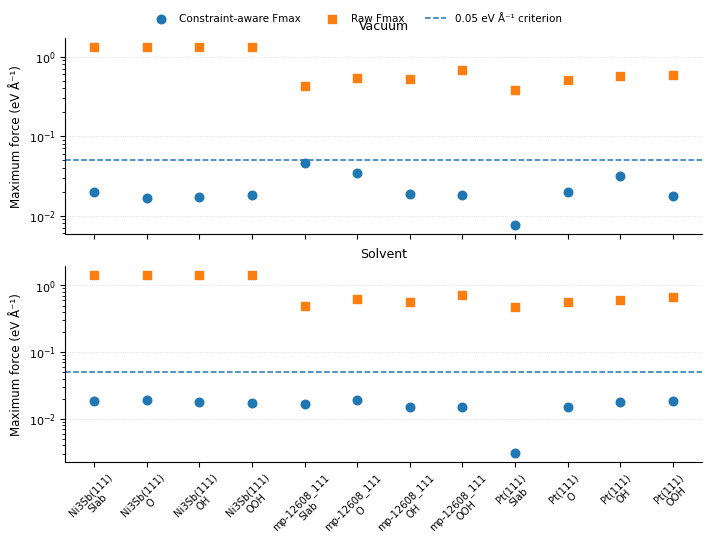

Saved force-convergence figure as PNG/PDF/SVG: /content/ML-accelerated-ORR/outputs/stageIII_vasp_demo/02_vasp_force_convergence


In [9]:
if "force_summary" not in globals():
    raise RuntimeError(
        "Run the Stage III force-convergence gate cell before plotting."
    )

# =============================================================================
# ACS-READY VACUUM + SOLVENT FORCE-CONVERGENCE DIAGNOSTIC
# =============================================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(7.0, 5.3),
    sharex=True,
    constrained_layout=True,
)

for axis, environment in zip(axes, ENVIRONMENTS):
    plot_df = force_summary[
        force_summary["environment"] == environment
    ].copy()

    labels = [
        f"{SURFACE_LABELS[system]}\n{state}"
        for system, state in zip(
            plot_df["system"],
            plot_df["state"],
        )
    ]

    x = np.arange(len(plot_df))

    axis.scatter(
        x,
        plot_df["max_force_free_eV_A"],
        marker="o",
        s=38,
        label="Constraint-aware Fmax",
        zorder=3,
    )

    axis.scatter(
        x,
        plot_df["max_force_raw_eV_A"],
        marker="s",
        s=28,
        label="Raw Fmax",
        zorder=2,
    )

    axis.axhline(
        FORCE_THRESHOLD_EV_A,
        linestyle="--",
        linewidth=1.1,
        label="0.05 eV Å⁻¹ criterion",
    )

    axis.set_yscale("log")
    axis.set_ylabel("Maximum force (eV Å⁻¹)", fontsize=8.5)
    axis.set_title(environment.capitalize(), fontsize=9)
    axis.tick_params(axis="y", labelsize=8)
    axis.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.5)
    axis.spines[["top", "right"]].set_visible(False)

axes[-1].set_xticks(np.arange(len(labels)), labels)
axes[-1].tick_params(axis="x", labelrotation=45, labelsize=7.2)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    legend_labels,
    frameon=False,
    fontsize=7.5,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
)

force_figure_stem = OUTPUT_DIR / "02_vasp_force_convergence"
save_publication_figure(fig, force_figure_stem)

plt.show()

print(
    "Saved force-convergence figure as PNG/PDF/SVG:",
    force_figure_stem,
)


## 6. Interactive visualization of the candidate intermediates

With the DFT convergence gate passed, the notebook inspects the actual vacuum
geometries used in the thermodynamic analysis. Interactive views are generated
for both shortlisted candidates, `mp-10260_111` and `mp-12608_111`.

The coordinates are read directly from the final `CONTCAR` files; no structure
is reconstructed or synthetically generated in this notebook.


In [10]:
SUPERCELL = (2, 2, 1)

# Deliberately distinct colors for the elements in the demonstration.
PREFERRED_ELEMENT_COLORS = {
    "H": "#E6E6E6",
    "O": "#E53935",
    "Pt": "#A7A9AC",
    "Ni": "#2E86AB",
    "Sb": "#8E44AD",
    "Fe": "#D35400",
    "Co": "#16A085",
    "Cu": "#C47F32",
    "Mn": "#7DCEA0",
    "Sn": "#5D6D7E",
}

FALLBACK_COLORS = (
    "#1F77B4",
    "#FF7F0E",
    "#2CA02C",
    "#9467BD",
    "#8C564B",
    "#E377C2",
    "#7F7F7F",
    "#BCBD22",
    "#17BECF",
)


def element_color_map(atoms: Atoms) -> dict[str, str]:
    """Return one distinct color for every element present."""
    elements = list(dict.fromkeys(atoms.get_chemical_symbols()))
    colors = {}
    fallback_index = 0

    for element in elements:
        if element in PREFERRED_ELEMENT_COLORS:
            colors[element] = PREFERRED_ELEMENT_COLORS[element]
        else:
            colors[element] = FALLBACK_COLORS[
                fallback_index % len(FALLBACK_COLORS)
            ]
            fallback_index += 1

    return colors


def atoms_to_cif_string(atoms: Atoms) -> str:
    # ASE's CIF writer expects a binary stream.
    buffer = io.BytesIO()
    write(buffer, atoms, format="cif")
    return buffer.getvalue().decode("latin-1")


def make_py3dmol_view(
    atoms: Atoms,
    *,
    repeat: tuple[int, int, int] = SUPERCELL,
    width: int = 800,
    height: int = 520,
):
    """Build a colored py3Dmol view of an ASE supercell."""
    supercell = atoms.repeat(repeat)
    supercell.wrap()

    colors = element_color_map(supercell)
    viewer = py3Dmol.view(width=width, height=height)
    viewer.addModel(atoms_to_cif_string(supercell), "cif")
    viewer.setBackgroundColor("white")

    # Start with a generic representation, then recolor every element.
    viewer.setStyle(
        {},
        {
            "sphere": {"scale": 0.30},
            "stick": {"radius": 0.12},
        },
    )

    for element, color in colors.items():
        sphere_scale = 0.40 if element in {"H", "O"} else 0.30
        viewer.setStyle(
            {"elem": element},
            {
                "sphere": {
                    "scale": sphere_scale,
                    "color": color,
                },
                "stick": {
                    "radius": 0.12,
                    "color": color,
                },
            },
        )

    viewer.addUnitCell()
    viewer.zoomTo()
    return viewer


STATE_LABELS = {
    "Slab": "Bare slab",
    "O": "O*",
    "OH": "OH*",
    "OOH": "OOH*",
}

for surface_id in CANDIDATE_IDS:
    print(
        f"\n{SURFACE_LABELS[surface_id]} ({surface_id})"
    )
    print("-" * 60)

    for state, label in STATE_LABELS.items():
        contcar = DATA_ROOT / surface_id / state / "CONTCAR"
        atoms = read_contcar(contcar)
        supercell_formula = atoms.repeat(SUPERCELL).get_chemical_formula(
            mode="metal"
        )

        print(
            f"{label} — "
            f"{SUPERCELL[0]}×{SUPERCELL[1]}×{SUPERCELL[2]} "
            f"supercell ({supercell_formula})"
        )
        make_py3dmol_view(atoms).show()



Ni3Sb(111) (mp-10260_111)
------------------------------------------------------------
Bare slab — 2×2×1 supercell (Ni144Sb48)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

O* — 2×2×1 supercell (Ni144O4Sb48)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

OH* — 2×2×1 supercell (Ni144H4O4Sb48)


...

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

OH* — 2×2×1 supercell (Cu48Pt336H4O4)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

OOH* — 2×2×1 supercell (Cu48Pt336H4O8)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 7. Static structure panels for the repository and Supporting Information

A compact top/side-view panel is exported for each of the three surfaces as
PNG, PDF, and SVG. This keeps the repository tutorial complete while allowing
the manuscript or Supporting Information to select only the panels needed for
the final presentation.


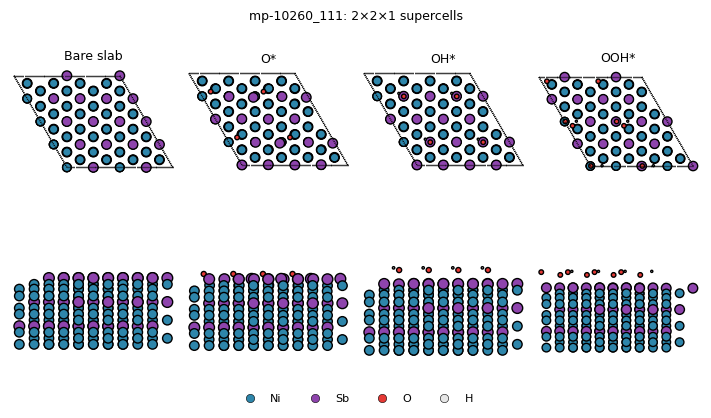

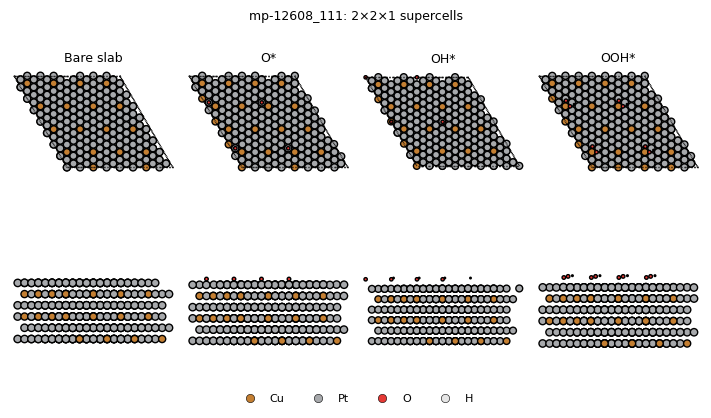

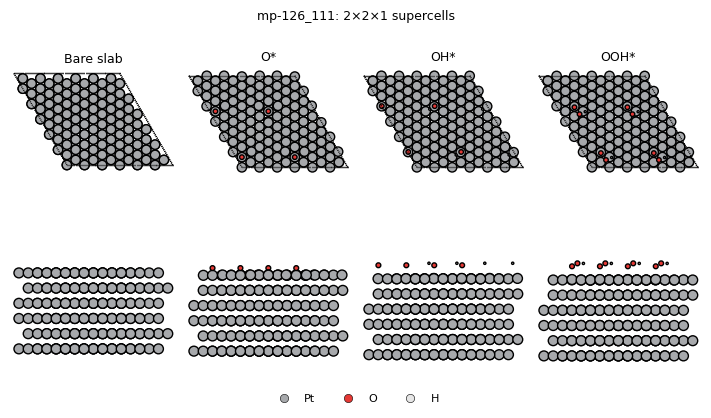

In [11]:
def plot_intermediate_structures(
    data_root: Path,
    surface_id: str,
    *,
    repeat: tuple[int, int, int] = SUPERCELL,
) -> plt.Figure:
    """Plot top and side views of colored repeated structures."""
    fig, axes = plt.subplots(
        2,
        4,
        figsize=(7.0, 4.0),
        constrained_layout=True,
    )

    legend_colors: dict[str, str] = {}

    for column, state in enumerate(SURFACE_STATES):
        atoms = read_contcar(
            data_root / surface_id / state / "CONTCAR"
        ).repeat(repeat)
        atoms.wrap()

        color_map = element_color_map(atoms)
        legend_colors.update(color_map)
        atom_colors = [
            color_map[element]
            for element in atoms.get_chemical_symbols()
        ]

        for row, rotation in enumerate(("0x,0y,0z", "-90x,0y,0z")):
            axis = axes[row, column]

            plot_atoms(
                atoms,
                axis,
                rotation=rotation,
                radii=0.55,
                colors=atom_colors,
                show_unit_cell=2 if row == 0 else 0,
            )
            axis.set_axis_off()

            if row == 0:
                axis.set_title(STATE_LABELS[state], fontsize=9)

            if column == 0:
                axis.set_ylabel(
                    "Top view" if row == 0 else "Side view",
                    fontsize=8,
                )

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markerfacecolor=color,
            markeredgecolor="black",
            markeredgewidth=0.4,
            markersize=6,
            label=element,
        )
        for element, color in legend_colors.items()
    ]

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=max(1, len(handles)),
        frameon=False,
        bbox_to_anchor=(0.5, -0.02),
        fontsize=8,
    )

    fig.suptitle(
        f"{surface_id}: {repeat[0]}×{repeat[1]}×{repeat[2]} supercells",
        fontsize=9,
    )
    return fig


for surface_id in SURFACE_IDS:
    structure_figure = plot_intermediate_structures(
        DATA_ROOT,
        surface_id,
    )

    save_publication_figure(
        structure_figure,
        OUTPUT_DIR / f"{surface_id}_intermediates_2x2x1",
    )

    plt.show()


## 8. Vacuum and solvent-aware adsorption Gibbs free energies

After the DFT geometry-convergence gate, each thermodynamic state is constructed
directly from the sigma-to-zero electronic energy and its explicit VaspGibbs
correction:

$$
G_{\mathrm{state}}
=
E_{\sigma\rightarrow 0,\mathrm{state}}
+
\left(
G-E_{\mathrm{DFT}}
\right)_{\mathrm{state}}.
$$

The vacuum H$_2$ and H$_2$O free energies define the computational hydrogen
electrode (CHE) references for the adsorbed O*, OH*, and OOH* intermediates:

$$
G_{\mathrm{ref}}(\mathrm{O}^*)
=
G_{\mathrm{H_2O}}^{\mathrm{vac}}
-
G_{\mathrm{H_2}}^{\mathrm{vac}},
$$

$$
G_{\mathrm{ref}}(\mathrm{OH}^*)
=
G_{\mathrm{H_2O}}^{\mathrm{vac}}
-
\frac{1}{2}
G_{\mathrm{H_2}}^{\mathrm{vac}},
$$

$$
G_{\mathrm{ref}}(\mathrm{OOH}^*)
=
2G_{\mathrm{H_2O}}^{\mathrm{vac}}
-
\frac{3}{2}
G_{\mathrm{H_2}}^{\mathrm{vac}}.
$$

For an adsorbate $X$ = O*, OH*, or OOH*, the corresponding adsorption Gibbs
free energy is evaluated as

$$
\Delta G_{X}
=
G_{\mathrm{slab}+X}
-
G_{\mathrm{slab}}
-
G_{\mathrm{ref}}(X).
$$

The same vacuum molecular references are used for both thermodynamic
environments. Vacuum adsorption free energies use the electronic energy from
the relaxed surface-state `OUTCAR`, whereas solvent-aware adsorption free
energies use the final electronic energy from the **relaxed** `Sol/OUTCAR`
calculation. In both cases, the state-specific correction from the vacuum
`Freq_vac/VaspGibbs.md` calculation is retained, following the thermodynamic
convention adopted for this Stage III analysis.

As an internal consistency check, the notebook independently reconstructs each
adsorption free energy from the corresponding total-$G$ expression and requires
numerical closure before proceeding to the ORR thermodynamic analysis.


In [12]:
def one_energy(
    table: pd.DataFrame,
    *,
    system: str,
    state: str,
    environment: str,
) -> pd.Series:
    selected = table[
        (table["system"] == system)
        & (table["state"] == state)
        & (table["environment"] == environment)
    ]

    if len(selected) != 1:
        raise ValueError(
            "Expected exactly one energy row for "
            f"{system}/{state}/{environment}; "
            f"found {len(selected)}."
        )

    return selected.iloc[0]


def vacuum_che_reference(
    table: pd.DataFrame,
    *,
    adsorbate: str,
) -> dict[str, float]:
    """
    Build a CHE reference using only vacuum H2 and H2O values.

    The returned reference is reused unchanged for vacuum and solvent
    adsorption calculations.
    """
    h2 = one_energy(
        table,
        system="H2",
        state="H2",
        environment="vacuum_reference",
    )
    h2o = one_energy(
        table,
        system="H2O",
        state="H2O",
        environment="vacuum_reference",
    )

    coefficients = {
        "O": (1.0, -1.0),
        "OH": (1.0, -0.5),
        "OOH": (2.0, -1.5),
    }
    n_h2o, n_h2 = coefficients[adsorbate]

    electronic_reference = (
        n_h2o * float(h2o["E_sigma0_eV"])
        + n_h2 * float(h2["E_sigma0_eV"])
    )
    correction_reference = (
        n_h2o * float(h2o["G_minus_Edft_eV"])
        + n_h2 * float(h2["G_minus_Edft_eV"])
    )
    gibbs_reference = (
        n_h2o * float(h2o["G_state_eV"])
        + n_h2 * float(h2["G_state_eV"])
    )

    return {
        "electronic_reference_eV": electronic_reference,
        "reference_correction_eV": correction_reference,
        "gibbs_reference_eV": gibbs_reference,
        "reference_environment": "vacuum H2/H2O",
    }


reference_rows = [
    {
        "adsorbate": adsorbate,
        **vacuum_che_reference(
            raw_energies,
            adsorbate=adsorbate,
        ),
    }
    for adsorbate in ADSORBATES
]
che_references = pd.DataFrame(reference_rows)
che_references.to_csv(
    OUTPUT_DIR / "03_CHE_vacuum_references.csv",
    index=False,
)

display(che_references)


adsorption_rows = []

for surface_id in SURFACE_IDS:
    for environment in ("vacuum", "solvent"):
        slab = one_energy(
            raw_energies,
            system=surface_id,
            state="Slab",
            environment=environment,
        )

        for adsorbate in ADSORBATES:
            adsorbed = one_energy(
                raw_energies,
                system=surface_id,
                state=adsorbate,
                environment=environment,
            )
            reference = vacuum_che_reference(
                raw_energies,
                adsorbate=adsorbate,
            )

            delta_e_sigma0 = (
                float(adsorbed["E_sigma0_eV"])
                - float(slab["E_sigma0_eV"])
                - reference["electronic_reference_eV"]
            )
            delta_g_correction = (
                float(adsorbed["G_minus_Edft_eV"])
                - float(slab["G_minus_Edft_eV"])
                - reference["reference_correction_eV"]
            )
            delta_g_adsorption = (
                delta_e_sigma0 + delta_g_correction
            )

            # Independent total-G expression for an auditable closure check.
            delta_g_direct = (
                float(adsorbed["G_state_eV"])
                - float(slab["G_state_eV"])
                - reference["gibbs_reference_eV"]
            )

            adsorption_rows.append(
                {
                    "slab": surface_id,
                    "environment": environment,
                    "adsorbate": adsorbate,
                    "DeltaE_sigma0_ads_eV": delta_e_sigma0,
                    "DeltaG_correction_ads_eV": delta_g_correction,
                    "DeltaG_ads_eV": delta_g_adsorption,
                    "closure_error_eV": (
                        delta_g_adsorption - delta_g_direct
                    ),
                    "molecular_reference": (
                        reference["reference_environment"]
                    ),
                    "adsorbed_E_sigma0_eV": (
                        float(adsorbed["E_sigma0_eV"])
                    ),
                    "slab_E_sigma0_eV": (
                        float(slab["E_sigma0_eV"])
                    ),
                    "adsorbed_G_minus_Edft_eV": (
                        float(adsorbed["G_minus_Edft_eV"])
                    ),
                    "slab_G_minus_Edft_eV": (
                        float(slab["G_minus_Edft_eV"])
                    ),
                    "adsorbed_OUTCAR": adsorbed["source_OUTCAR"],
                    "slab_OUTCAR": slab["source_OUTCAR"],
                    "adsorbed_VaspGibbs": (
                        adsorbed["source_VaspGibbs"]
                    ),
                    "slab_VaspGibbs": slab["source_VaspGibbs"],
                }
            )

adsorption_gibbs = pd.DataFrame(adsorption_rows)

if not adsorption_gibbs["closure_error_eV"].abs().lt(1e-8).all():
    raise ArithmeticError(
        "The E_sigma0 + correction decomposition failed its closure check."
    )

vacuum_lookup = (
    adsorption_gibbs[
        adsorption_gibbs["environment"] == "vacuum"
    ]
    .set_index(["slab", "adsorbate"])["DeltaG_ads_eV"]
)

adsorption_gibbs["DeltaG_solvation_eV"] = [
    (
        row.DeltaG_ads_eV
        - float(vacuum_lookup.loc[(row.slab, row.adsorbate)])
        if row.environment == "solvent"
        else 0.0
    )
    for row in adsorption_gibbs.itertuples()
]

adsorption_gibbs.to_csv(
    OUTPUT_DIR / "04_adsorption_gibbs_free_energies.csv",
    index=False,
)

display(adsorption_gibbs)


,adsorbate,electronic_reference_eV,reference_correction_eV,gibbs_reference_eV,reference_environment
0,O,-7.196685,0.127768,-7.068917,vacuum H2/H2O
1,OH,-10.685913,0.105922,-10.579991,vacuum H2/H2O
2,OOH,-17.882598,0.233690,-17.648908,vacuum H2/H2O


,slab,environment,adsorbate,DeltaE_sigma0_ads_eV,DeltaG_correction_ads_eV,DeltaG_ads_eV,closure_error_eV,molecular_reference,adsorbed_E_sigma0_eV,slab_E_sigma0_eV,adsorbed_G_minus_Edft_eV,slab_G_minus_Edft_eV,adsorbed_OUTCAR,slab_OUTCAR,adsorbed_VaspGibbs,slab_VaspGibbs,DeltaG_solvation_eV
0,mp-10260_111,vacuum,O,1.693686,-0.122369,1.571317,1.199041e-14,vacuum H2/H2O,-244.751370,-239.248371,-0.326735,-0.332134,/content/stageIII_vasp_demo/mp-10260_111/O/OUTCAR,/content/stageIII_vasp_demo/mp-10260_111/Slab/...,/content/stageIII_vasp_demo/mp-10260_111/O/Fre...,/content/stageIII_vasp_demo/mp-10260_111/Slab/...,0.000000
1,mp-10260_111,vacuum,OH,0.730518,0.099883,0.830401,1.321165e-14,vacuum H2/H2O,-249.203766,-239.248371,-0.126329,-0.332134,/content/stageIII_vasp_demo/mp-10260_111/OH/OU...,/content/stageIII_vasp_demo/mp-10260_111/Slab/...,/content/stageIII_vasp_demo/mp-10260_111/OH/Fr...,/content/stageIII_vasp_demo/mp-10260_111/Slab/...,0.000000
2,mp-10260_111,vacuum,OOH,3.932883,0.002239,3.935121,8.881784e-16,vacuum H2/H2O,-253.198086,-239.248371,-0.096206,-0.332134,/content/stageIII_vasp_demo/mp-10260_111/OOH/O...,/content/stageIII_vasp_demo/mp-10260_111/Slab/...,/content/stageIII_vasp_demo/mp-10260_111/OOH/F...,/content/stageIII_vasp_demo/mp-10260_111/Slab/...,0.000000
3,mp-10260_111,solvent,O,1.618416,-0.122369,1.496047,1.199041e-14,vacuum H2/H2O,-244.876053,-239.297784,-0.326735,-0.332134,/content/stageIII_vasp_demo/mp-10260_111/O/Sol...,/content/stageIII_vasp_demo/mp-10260_111/Slab/...,/content/stageIII_vasp_demo/mp-10260_111/O/Fre...,/content/stageIII_vasp_demo/mp-10260_111/Slab/...,-0.075270
4,mp-10260_111,solvent,OH,0.564506,0.099883,0.664390,1.321165e-14,vacuum H2/H2O,-249.419190,-239.297784,-0.126329,-0.332134,/content/stageIII_vasp_demo/mp-10260_111/OH/So...,/content/stageIII_vasp_demo/mp-10260_111/Slab/...,/content/stageIII_vasp_demo/mp-10260_111/OH/Fr...,/content/stageIII_vasp_demo/mp-10260_111/Slab/...,-0.166011
5,mp-10260_111,solvent,OOH,3.719728,0.002239,3.721967,8.881784e-16,vacuum H2/H2O,-253.460653,-239.297784,-0.096206,-0.332134,/content/stageIII_vasp_demo/mp-10260_111/OOH/S...,/content/stageIII_vasp_demo/mp-10260_111/Slab/...,/content/stageIII_vasp_demo/mp-10260_111/OOH/F...,/content/stageIII_vasp_demo/mp-10260_111/Slab/...,-0.213155
6,mp-12608_111,vacuum,O,1.274200,-0.052293,1.221907,-9.725554e-14,vacuum H2/H2O,-577.099103,-571.176618,-1.018660,-1.094135,/content/stageIII_vasp_demo/mp-12608_111/O/OUTCAR,/content/stageIII_vasp_demo/mp-12608_111/Slab/...,/content/stageIII_vasp_demo/mp-12608_111/O/Fre...,/content/stageIII_vasp_demo/mp-12608_111/Slab/...,0.000000
7,mp-12608_111,vacuum,OH,0.667253,0.109775,0.777027,-3.608225e-14,vacuum H2/H2O,-581.195279,-571.176618,-0.878439,-1.094135,/content/stageIII_vasp_demo/mp-12608_111/OH/OU...,/content/stageIII_vasp_demo/mp-12608_111/Slab/...,/content/stageIII_vasp_demo/mp-12608_111/OH/Fr...,/content/stageIII_vasp_demo/mp-12608_111/Slab/...,0.000000
8,mp-12608_111,vacuum,OOH,3.573150,0.103033,3.676183,-8.704149e-14,vacuum H2/H2O,-585.486066,-571.176618,-0.757412,-1.094135,/content/stageIII_vasp_demo/mp-12608_111/OOH/O...,/content/stageIII_vasp_demo/mp-12608_111/Slab/...,/content/stageIII_vasp_demo/mp-12608_111/OOH/F...,/content/stageIII_vasp_demo/mp-12608_111/Slab/...,0.000000
9,mp-12608_111,solvent,O,1.261438,-0.052293,1.209145,-9.725554e-14,vacuum H2/H2O,-577.068031,-571.132784,-1.018660,-1.094135,/content/stageIII_vasp_demo/mp-12608_111/O/Sol...,/content/stageIII_vasp_demo/mp-12608_111/Slab/...,/content/stageIII_vasp_demo/mp-12608_111/O/Fre...,/content/stageIII_vasp_demo/mp-12608_111/Slab/...,-0.012762


## 9. ORR limiting potential, PDS, and overpotential

For the four-electron associative ORR pathway, the limiting potentials
associated with the four proton–electron transfer steps are evaluated as

$$
U_1
=
4.92
-
\Delta G_{\mathrm{OOH}},
$$

$$
U_2
=
\Delta G_{\mathrm{OOH}}
-
\Delta G_{\mathrm{O}},
$$

$$
U_3
=
\Delta G_{\mathrm{O}}
-
\Delta G_{\mathrm{OH}},
$$

$$
U_4
=
\Delta G_{\mathrm{OH}}.
$$

Here, the total free-energy change for the four-electron reduction of
O$_2$ to H$_2$O is taken as $4.92$ eV, corresponding to an equilibrium
potential of $1.23$ V.

The limiting potential is defined as

$$
U_L
=
\min
\left(
U_1,
U_2,
U_3,
U_4
\right),
$$

and the corresponding thermodynamic ORR overpotential is

$$
\eta_{\mathrm{ORR}}
=
1.23
-
U_L.
$$

The reaction step associated with the minimum $U_i$ is identified as the
potential-determining step (PDS).

The same thermodynamic expressions are applied independently to the vacuum
and solvent-aware adsorption free energies, enabling a direct comparison of
the predicted ORR activity under the two energetic treatments.

In [13]:
def calculate_orr(
    adsorption: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for (surface_id, environment), group in adsorption.groupby(
        ["slab", "environment"],
        sort=True,
    ):
        values = group.set_index("adsorbate")["DeltaG_ads_eV"]

        missing = [
            adsorbate
            for adsorbate in ADSORBATES
            if adsorbate not in values.index
        ]

        if missing:
            raise ValueError(
                f"{surface_id}/{environment} is missing {missing}."
            )

        g_o = float(values["O"])
        g_oh = float(values["OH"])
        g_ooh = float(values["OOH"])

        steps = {
            "U1": TOTAL_ORR_FREE_ENERGY_EV - g_ooh,
            "U2": g_ooh - g_o,
            "U3": g_o - g_oh,
            "U4": g_oh,
        }

        pds_key = min(steps, key=steps.get)
        limiting_potential = steps[pds_key]

        rows.append(
            {
                "slab": surface_id,
                "environment": environment,
                "G_O_eV": g_o,
                "G_OH_eV": g_oh,
                "G_OOH_eV": g_ooh,
                "U1_O2_to_OOH_V": steps["U1"],
                "U2_OOH_to_O_V": steps["U2"],
                "U3_O_to_OH_V": steps["U3"],
                "U4_OH_to_H2O_V": steps["U4"],
                "U_L_ORR_V": limiting_potential,
                "eta_ORR_V": (
                    EQUILIBRIUM_POTENTIAL_V - limiting_potential
                ),
                "PDS_key": pds_key,
                "PDS": PDS_LABELS[pds_key],
            }
        )

    return pd.DataFrame(rows)


orr_results = calculate_orr(adsorption_gibbs)

pt_eta = (
    orr_results[
        orr_results["slab"] == PT_REFERENCE
    ]
    .set_index("environment")["eta_ORR_V"]
)

orr_results["Pt_reference"] = PT_REFERENCE
orr_results["Pt_eta_ORR_V"] = [
    float(pt_eta.loc[environment])
    for environment in orr_results["environment"]
]
orr_results["delta_eta_vs_Pt_V"] = (
    orr_results["eta_ORR_V"] - orr_results["Pt_eta_ORR_V"]
)
orr_results["better_than_Pt"] = (
    orr_results["delta_eta_vs_Pt_V"] < 0.0
)

orr_results["rank_by_eta"] = (
    orr_results
    .groupby("environment")["eta_ORR_V"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

orr_results = orr_results.sort_values(
    ["environment", "eta_ORR_V", "slab"]
).reset_index(drop=True)

orr_results.to_csv(
    OUTPUT_DIR / "05_ORR_overpotential_and_PDS.csv",
    index=False,
)

display(
    orr_results[
        [
            "slab",
            "environment",
            "U_L_ORR_V",
            "eta_ORR_V",
            "rank_by_eta",
            "PDS",
            "delta_eta_vs_Pt_V",
            "better_than_Pt",
        ]
    ]
)


,slab,environment,U_L_ORR_V,eta_ORR_V,rank_by_eta,PDS,delta_eta_vs_Pt_V,better_than_Pt
0,mp-10260_111,solvent,0.664390,0.565610,1,OH* → H2O,-0.266370,True
1,mp-12608_111,solvent,0.569665,0.660335,2,O* → OH*,-0.171645,True
2,mp-126_111,solvent,0.398020,0.831980,3,O* → OH*,0.000000,False
3,mp-10260_111,vacuum,0.740916,0.489084,1,O* → OH*,-0.467790,True
4,mp-12608_111,vacuum,0.444880,0.785120,2,O* → OH*,-0.171754,True
5,mp-126_111,vacuum,0.273126,0.956874,3,O* → OH*,0.000000,False


## 10. Vacuum and solvent ORR free-energy diagrams

The diagrams are evaluated at the equilibrium potential $U=1.23$ V. At this
potential, the largest uphill proton–electron-transfer step identifies the
thermodynamic bottleneck. The PDS is highlighted explicitly.

A matched vacuum/solvent diagram is exported for each shortlisted candidate and
for Pt(111), so every activity value in the comparison can be traced back to
its individual ORR free-energy profile.


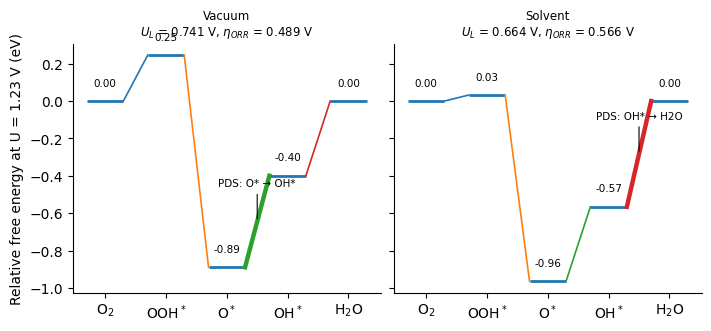

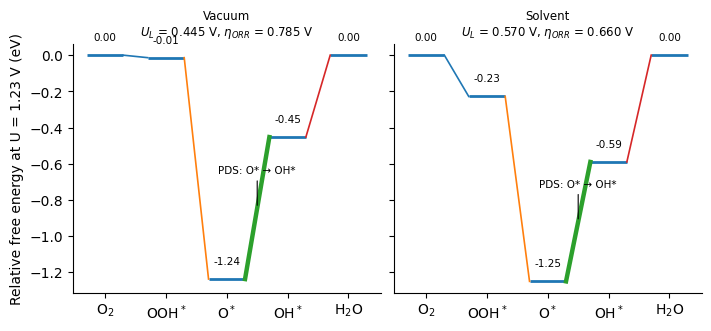

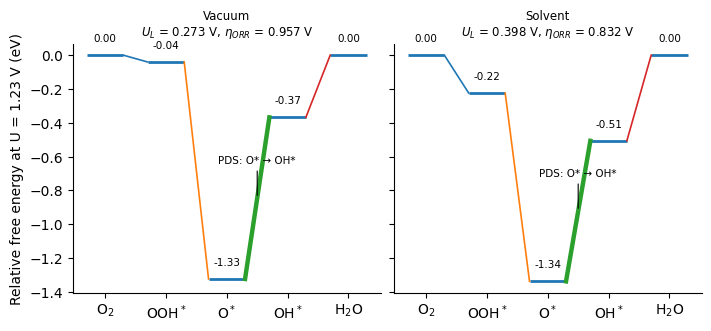

In [14]:
def reaction_levels_at_potential(
    row: pd.Series,
    potential_v: float,
) -> list[float]:
    step_potentials = np.array(
        [
            row["U1_O2_to_OOH_V"],
            row["U2_OOH_to_O_V"],
            row["U3_O_to_OH_V"],
            row["U4_OH_to_H2O_V"],
        ],
        dtype=float,
    )

    step_free_energies = -step_potentials + potential_v

    levels = [0.0]

    for step_delta_g in step_free_energies:
        levels.append(levels[-1] + float(step_delta_g))

    return levels


def plot_free_energy_diagrams(
    results: pd.DataFrame,
    *,
    surface_id: str,
    potential_v: float = 1.23,
) -> plt.Figure:
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(7.0, 3.2),
        sharey=True,
        constrained_layout=True,
    )

    state_labels = [
        r"$\mathrm{O_2}$",
        r"$\mathrm{OOH^*}$",
        r"$\mathrm{O^*}$",
        r"$\mathrm{OH^*}$",
        r"$\mathrm{H_2O}$",
    ]

    for axis, environment in zip(axes, ("vacuum", "solvent")):
        selected = results[
            (results["slab"] == surface_id)
            & (results["environment"] == environment)
        ]

        if len(selected) != 1:
            raise ValueError(
                f"No unique ORR result for {surface_id}/{environment}."
            )

        row = selected.iloc[0]
        levels = reaction_levels_at_potential(row, potential_v)

        pds_index = {
            "U1": 0,
            "U2": 1,
            "U3": 2,
            "U4": 3,
        }[row["PDS_key"]]

        for index, level in enumerate(levels):
            axis.hlines(
                level,
                index - 0.30,
                index + 0.30,
                linewidth=2.0,
            )
            axis.text(
                index,
                level + 0.07,
                f"{level:.2f}",
                ha="center",
                va="bottom",
                fontsize=7.5,
            )

        for index in range(4):
            linewidth = 3.2 if index == pds_index else 1.2
            axis.plot(
                [index + 0.30, index + 0.70],
                [levels[index], levels[index + 1]],
                linewidth=linewidth,
            )

        axis.annotate(
            f"PDS: {row['PDS']}",
            xy=(
                pds_index + 0.5,
                (levels[pds_index] + levels[pds_index + 1]) / 2,
            ),
            xytext=(0, 25),
            textcoords="offset points",
            ha="center",
            fontsize=7.5,
            arrowprops={
                "arrowstyle": "-",
                "linewidth": 0.8,
            },
        )

        axis.set_xticks(range(5), state_labels)
        axis.set_title(
            f"{environment.capitalize()}\n"
            f"$U_L$ = {row['U_L_ORR_V']:.3f} V, "
            f"$\\eta_{{ORR}}$ = {row['eta_ORR_V']:.3f} V",
            fontsize=8.5,
        )
        axis.spines[["top", "right"]].set_visible(False)

    axes[0].set_ylabel(
        f"Relative free energy at U = {potential_v:.2f} V (eV)"
    )

    return fig


for surface_id in SURFACE_IDS:
    free_energy_figure = plot_free_energy_diagrams(
        orr_results,
        surface_id=surface_id,
        potential_v=EQUILIBRIUM_POTENTIAL_V,
    )

    save_publication_figure(
        free_energy_figure,
        OUTPUT_DIR / f"{surface_id}_vacuum_and_solvent_ORR",
    )

    plt.show()


## 11. Three-surface ORR activity comparison

The final activity comparison places the primary Ni$_3$Sb(111) candidate,
`mp-12608_111`, and Pt(111) on the same thermodynamic footing. Vacuum and
implicit-solvent overpotentials are shown side by side, and the PDS is retained
in the numerical table for each surface/environment combination.

Because Pt(111) is recalculated within the same workflow, differences in
$\eta_{\mathrm{ORR}}$ are evaluated directly against the matched Pt reference
rather than against an external literature number.


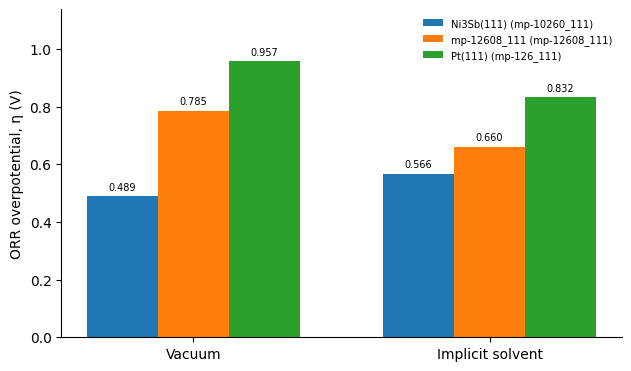

In [15]:
def plot_overpotential_comparison(
    results: pd.DataFrame,
    *,
    surfaces: tuple[str, ...],
) -> plt.Figure:
    """Compare all requested surfaces in vacuum and implicit solvent."""
    environments = ("vacuum", "solvent")

    x = np.arange(len(environments))
    width = 0.24

    fig, axis = plt.subplots(
        figsize=(6.2, 3.6),
        constrained_layout=True,
    )

    n_surfaces = len(surfaces)

    for surface_index, surface_id in enumerate(surfaces):
        values = []

        for environment in environments:
            selected = results[
                (results["slab"] == surface_id)
                & (results["environment"] == environment)
            ]

            if len(selected) != 1:
                raise ValueError(
                    f"No unique ORR result for "
                    f"{surface_id}/{environment}."
                )

            row = selected.iloc[0]
            values.append(float(row["eta_ORR_V"]))

        offset = (
            surface_index - (n_surfaces - 1) / 2
        ) * width
        positions = x + offset

        bars = axis.bar(
            positions,
            values,
            width,
            label=f"{SURFACE_LABELS[surface_id]} ({surface_id})",
        )

        for bar, value in zip(bars, values):
            axis.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=7,
            )

    axis.set_xticks(x, ["Vacuum", "Implicit solvent"])
    axis.set_ylabel("ORR overpotential, η (V)")
    axis.legend(frameon=False, fontsize=7.2)
    axis.spines[["top", "right"]].set_visible(False)

    upper_limit = results["eta_ORR_V"].max() + 0.18
    axis.set_ylim(0.0, upper_limit)

    return fig


overpotential_figure = plot_overpotential_comparison(
    orr_results,
    surfaces=SURFACE_IDS,
)

save_publication_figure(
    overpotential_figure,
    OUTPUT_DIR / "three_surface_ORR_overpotential_comparison",
)

plt.show()


## 12. Export provenance and package the reproducible outputs

The metadata file records the electronic-energy convention, force-convergence
definition, thermodynamic correction path, solvent convention, software
versions, and ORR constants used in this run.


In [16]:
force_validation_by_environment = {}

for environment in ENVIRONMENTS:
    selected = force_summary[
        force_summary["environment"] == environment
    ]

    force_validation_by_environment[environment] = {
        "structures_evaluated": int(len(selected)),
        "structures_passed": int(
            (selected["status"] == "PASS").sum()
        ),
        "minimum_Fmax_free_eV_A": float(
            selected["max_force_free_eV_A"].min()
        ),
        "mean_Fmax_free_eV_A": float(
            selected["max_force_free_eV_A"].mean()
        ),
        "maximum_Fmax_free_eV_A": float(
            selected["max_force_free_eV_A"].max()
        ),
    }


run_metadata = {
    "repository": REPO_URL,
    "repository_ref": REPO_REF,
    "compressed_demo_data": {
        "archive_root": str(ARCHIVE_ROOT),
        "runtime_data_root": str(DATA_ROOT),
        "archives": archive_manifest.to_dict(orient="records"),
    },
    "data_root": str(DATA_ROOT),
    "surfaces": list(SURFACE_IDS),
    "surface_labels": SURFACE_LABELS,
    "primary_candidate": PRIMARY_CANDIDATE,
    "comparison_candidate": COMPARISON_CANDIDATE,
    "pt_reference": PT_REFERENCE,
    "required_files": file_audit["file"].tolist(),
    "software": {
        "python": sys.version.split()[0],
        "ase": ase.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": matplotlib.__version__,
    },
    "electronic_energy": (
        "last energy(sigma->0) parsed directly from each OUTCAR"
    ),
    "dft_force_validation": {
        "threshold_eV_A": FORCE_THRESHOLD_EV_A,
        "environments": list(ENVIRONMENTS),
        "criterion": (
            "maximum atomic force norm after applying selective-dynamics "
            "constraints to the final ionic frame"
        ),
        "raw_force_role": (
            "reported for transparency only; includes constrained coordinates"
        ),
        "rms_force_role": (
            "component-wise secondary diagnostic; not the stopping criterion"
        ),
        "frequency_force_evaluation": False,
        "vacuum_force_evaluation": True,
        "solvent_force_evaluation": True,
        "solvent_constraint_policy": (
            "prefer Sol/CONTCAR; otherwise reuse the corresponding vacuum "
            "CONTCAR constraint mask while reading final positions/forces "
            "from Sol/OUTCAR"
        ),
        "summary_by_environment": force_validation_by_environment,
    },
    "thermal_correction": (
        "explicit G - E_dft from each vacuum Freq_vac/VaspGibbs.md"
    ),
    "state_free_energy": "G_state = E_sigma0 + (G - E_dft)",
    "molecular_reference": (
        "vacuum H2 and H2O used unchanged for vacuum and solvent surfaces"
    ),
    "solvent_convention": (
        "final relaxed Sol/OUTCAR sigma0 electronic energies for surface "
        "states; vacuum state corrections and vacuum molecular references "
        "retained"
    ),
    "visualization_supercell": list(SUPERCELL),
    "visualization_colors": PREFERRED_ELEMENT_COLORS,
    "orr_equilibrium_potential_V": EQUILIBRIUM_POTENTIAL_V,
    "overall_ORR_free_energy_eV": TOTAL_ORR_FREE_ENERGY_EV,
}

metadata_path = OUTPUT_DIR / "06_run_metadata.json"
metadata_path.write_text(
    json.dumps(run_metadata, indent=2) + "\n",
    encoding="utf-8",
)

archive_path = shutil.make_archive(
    str(OUTPUT_DIR),
    "zip",
    root_dir=OUTPUT_DIR,
)

print("Results directory:", OUTPUT_DIR)
print("Metadata:         ", metadata_path)
print("Download archive: ", archive_path)

for path in sorted(OUTPUT_DIR.iterdir()):
    print(
        f"{path.name:60s} "
        f"{path.stat().st_size / 1024:.1f} kB"
    )

if IN_COLAB:
    from google.colab import files

    files.download(archive_path)


Results directory: /content/ML-accelerated-ORR/outputs/stageIII_vasp_demo
Metadata:          /content/ML-accelerated-ORR/outputs/stageIII_vasp_demo/06_run_metadata.json
Download archive:  /content/ML-accelerated-ORR/outputs/stageIII_vasp_demo.zip
00_demo_archive_manifest.csv                                 0.7 kB
01_raw_vasp_energies_and_force_diagnostics.csv               15.5 kB
02_vasp_force_convergence.csv                                4.8 kB
02_vasp_force_convergence.pdf                                19.4 kB
02_vasp_force_convergence.png                                325.6 kB
02_vasp_force_convergence.svg                                66.8 kB
02b_vasp_force_convergence_summary.csv                       0.8 kB
03_CHE_vacuum_references.csv                                 0.3 kB
04_adsorption_gibbs_free_energies.csv                        7.6 kB
05_ORR_overpotential_and_PDS.csv                             1.7 kB
06_run_metadata.json                                         6.0 kB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Output files and interpretation

The notebook exports:

```text
outputs/stageIII_vasp_demo/
├── 00_demo_archive_manifest.csv
├── 01_raw_vasp_energies_and_force_diagnostics.csv
├── 02_vasp_force_convergence.csv
├── 02b_vasp_force_convergence_summary.csv
├── 02_vasp_force_convergence.{png,pdf,svg}
├── 03_CHE_vacuum_references.csv
├── 04_adsorption_gibbs_free_energies.csv
├── 05_ORR_overpotential_and_PDS.csv
├── 06_run_metadata.json
├── mp-10260_111_intermediates_2x2x1.{png,pdf,svg}
├── mp-12608_111_intermediates_2x2x1.{png,pdf,svg}
├── mp-126_111_intermediates_2x2x1.{png,pdf,svg}
├── mp-10260_111_vacuum_and_solvent_ORR.{png,pdf,svg}
├── mp-12608_111_vacuum_and_solvent_ORR.{png,pdf,svg}
├── mp-126_111_vacuum_and_solvent_ORR.{png,pdf,svg}
└── three_surface_ORR_overpotential_comparison.{png,pdf,svg}
```

### What this notebook establishes

1. The public Stage III thermodynamics are reconstructed from committed VASP
   and VaspGibbs outputs rather than synthetic values.
2. Every vacuum **and relaxed implicit-solvent** DFT geometry entering the
   three-surface thermodynamic analysis is checked against the same
   constraint-aware force threshold.
3. Large raw forces on fixed slab coordinates are preserved as diagnostics but
   are not misidentified as unconverged mobile degrees of freedom.
4. Molecular finite-displacement frequency calculations are kept outside the
   ionic convergence claim.
5. Adsorption free energies are decomposed into electronic and thermodynamic
   contributions and independently checked for algebraic closure.
6. Ni$_3$Sb(111), `mp-12608_111`, and Pt(111) are evaluated under the same CHE,
   VaspGibbs, and solvent conventions.

### Manuscript-ready Methods wording

> Force convergence of the final DFT-relaxed structures was evaluated from the
> atomic forces in the final VASP ionic configuration for both vacuum and
> implicit-solvent calculations. For slab models containing fixed layers,
> selective-dynamics constraints were applied before evaluating the residual
> forces, and convergence was defined using the maximum force magnitude over
> the unconstrained degrees of freedom, $F_{\max}^{\mathrm{free}}$. Structures
> were accepted when $F_{\max}^{\mathrm{free}} < 0.05$ eV Å$^{-1}$. Raw forces
> on constrained coordinates were retained only as diagnostics. Molecular
> finite-displacement frequency calculations were not included in the ionic
> convergence assessment.

### Interpretation boundary

The force analysis establishes **ionic convergence of the final vacuum and
implicit-solvent DFT geometries** used for the thermodynamic analysis. It should
not be interpreted as a direct MLIP–DFT force-error benchmark.

Licensed VASP `POTCAR` files are neither required by this notebook nor
redistributed in the repository.


In [17]:
# =============================================================================
# COPY-READY RUNTIME SUMMARY FOR MANUSCRIPT / SUPPORTING INFORMATION
# =============================================================================

print("Force-convergence summary")
print("=" * 72)

for environment in ENVIRONMENTS:
    selected = force_summary[
        force_summary["environment"] == environment
    ]

    n_total = len(selected)
    n_passed = int((selected["status"] == "PASS").sum())
    fmin = selected["max_force_free_eV_A"].min()
    fmean = selected["max_force_free_eV_A"].mean()
    fmax = selected["max_force_free_eV_A"].max()

    print(
        f"{environment.capitalize()}: "
        f"{n_passed}/{n_total} structures pass; "
        f"Fmax(free) = {fmin:.4f}–{fmax:.4f} eV/Å "
        f"(mean {fmean:.4f} eV/Å)."
    )

print("\nORR activity summary")
print("=" * 72)

display(
    orr_results[
        [
            "slab",
            "environment",
            "G_O_eV",
            "G_OH_eV",
            "G_OOH_eV",
            "U_L_ORR_V",
            "eta_ORR_V",
            "rank_by_eta",
            "PDS",
            "delta_eta_vs_Pt_V",
            "better_than_Pt",
        ]
    ]
)


Force-convergence summary
Vacuum: 12/12 structures pass; Fmax(free) = 0.0076–0.0455 eV/Å (mean 0.0221 eV/Å).
Solvent: 12/12 structures pass; Fmax(free) = 0.0031–0.0189 eV/Å (mean 0.0162 eV/Å).

ORR activity summary


,slab,environment,G_O_eV,G_OH_eV,G_OOH_eV,U_L_ORR_V,eta_ORR_V,rank_by_eta,PDS,delta_eta_vs_Pt_V,better_than_Pt
0,mp-10260_111,solvent,1.496047,0.664390,3.721967,0.664390,0.565610,1,OH* → H2O,-0.266370,True
1,mp-12608_111,solvent,1.209145,0.639480,3.461987,0.569665,0.660335,2,O* → OH*,-0.171645,True
2,mp-126_111,solvent,1.120839,0.722819,3.465758,0.398020,0.831980,3,O* → OH*,0.000000,False
3,mp-10260_111,vacuum,1.571317,0.830401,3.935121,0.740916,0.489084,1,O* → OH*,-0.467790,True
4,mp-12608_111,vacuum,1.221907,0.777027,3.676183,0.444880,0.785120,2,O* → OH*,-0.171754,True
5,mp-126_111,vacuum,1.134992,0.861866,3.649412,0.273126,0.956874,3,O* → OH*,0.000000,False
